# Bank Term Deposit Subscription Prediction

## 1. Problem Framing

### Business Problem

Banks run direct marketing campaigns to promote term deposit products, but not every contacted customer is equally likely to subscribe.

The goal of this project is to build a binary classification model that predicts whether a bank customer is likely to subscribe to a term deposit.

The model is intended to support marketing teams in prioritizing customer outreach and understanding subscription likelihood.

### Prediction Timing

Predictions are assumed to be made immediately before a marketing contact, using only information that would reasonably be available at that time.

This timing is important because features that become available only during or after the contact must not be used in the final predictive model.

### Target Variable

The target variable is `y`:

- `yes` — the customer subscribed to a term deposit.
- `no` — the customer did not subscribe.

The positive class is `yes`.

### Intended Use

The model is intended as a decision-support tool for campaign prioritization and analysis.

It should not be used to:

- determine eligibility for financial products,
- automatically exclude customers from receiving offers,
- make lending or credit decisions,
- replace human decision-making.

### Prediction Errors

A **false positive** occurs when the model predicts that a customer will subscribe, but the customer does not. This may result in unnecessary marketing effort.

A **false negative** occurs when the model predicts that a customer will not subscribe, but the customer actually would. This may cause a potentially interested customer to be deprioritized.

These trade-offs will be considered when defining the evaluation strategy.

## 2. Evaluation Strategy

### Primary Metric

The primary evaluation metric will be **Average Precision (AP)**.

The positive class represents customers who subscribe to the term deposit. Because this class is less frequent than the non-subscription class, accuracy alone may provide a misleading view of model quality.

Average Precision summarizes the precision-recall trade-off across decision thresholds and provides a more informative measure of how effectively the model identifies potential subscribers.

### Secondary Metrics

The following metrics will also be reported:

- **Precision** — measures how many customers predicted to subscribe actually subscribe.
- **Recall** — measures how many actual subscribers are successfully identified.
- **F1-score** — summarizes the balance between precision and recall.
- **ROC-AUC** — measures the model's overall ability to rank subscribers above non-subscribers.
- **Confusion Matrix** — shows the number of true positives, true negatives, false positives, and false negatives.

Accuracy may be reported for context but will not be used as the main model-selection metric.

### Validation Strategy

The full dataset is ordered chronologically from May 2008 to November 2010.

To better represent deployment on future marketing campaigns, the data will therefore not be randomly shuffled before the final split.

The earliest 80% of observations will be used as the training and development set, while the latest 20% will be reserved as an out-of-time test set.

Within the training data, time-aware cross-validation will be used for model comparison and hyperparameter tuning.

This strategy reduces the risk of training on future economic conditions when evaluating predictions for earlier periods.

The held-out test set will not be used for model selection, hyperparameter tuning, or threshold selection.

### Model Selection

Models will primarily be compared using cross-validated Average Precision. Precision, recall, F1-score, ROC-AUC, and variation across validation folds will be used as supporting evidence.

Decision-threshold analysis will be performed later using validation data rather than the held-out test set.

## 3. Data Understanding and Quality Audit

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "bank-additional-full.csv"

df = pd.read_csv(DATA_PATH, sep=";")

In [2]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 41188
Columns: 21


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
y,,
no,36548,88.734583
yes,4640,11.265417


In [6]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [16]:
categorical_columns = (
    df.drop(columns="y")
    .select_dtypes(exclude=np.number)
    .columns
)
unknown_counts = {}

for column in categorical_columns:
    unknown_counts[column] = (df[column] == "unknown").sum()

unknown_summary = (
    pd.Series(unknown_counts)
    .sort_values(ascending=False)
    .to_frame("unknown_count")
)

unknown_summary["percentage"] = (
    unknown_summary["unknown_count"] / len(df) * 100
)

unknown_summary

,unknown_count,percentage
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


In [8]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 4),
    "%"
)

Exact duplicate rows: 12
Duplicate percentage: 0.0291 %


In [9]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

In [10]:
df.nunique().sort_values()

contact              2
y                    2
default              3
loan                 3
poutcome             3
housing              3
marital              4
day_of_week          5
previous             8
education            8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [12]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [13]:
print(
    "pdays = 999:",
    (df["pdays"] == 999).sum()
)

pdays = 999: 39673


In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column:20s}",
        "min =", df[column].min(),
        "max =", df[column].max()
    )

age                  min = 17 max = 98
duration             min = 0 max = 4918
campaign             min = 1 max = 56
pdays                min = 0 max = 999
previous             min = 0 max = 7
emp.var.rate         min = -3.4 max = 1.4
cons.price.idx       min = 92.201 max = 94.767
cons.conf.idx        min = -50.8 max = -26.9
euribor3m            min = 0.634 max = 5.045
nr.employed          min = 4963.6 max = 5228.1


### Feature Groups

**Customer characteristics**
- `age`
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`

**Current campaign information**
- `contact`
- `month`
- `day_of_week`
- `duration`
- `campaign`

**Previous campaign information**
- `pdays`
- `previous`
- `poutcome`

**Economic context**
- `emp.var.rate`
- `cons.price.idx`
- `cons.conf.idx`
- `euribor3m`
- `nr.employed`

**Target**
- `y`

### Initial Data Quality Findings

- The dataset contains 41,188 observations and 21 columns.
- The target `y` is imbalanced: approximately 88.7% non-subscribers and 11.3% subscribers.
- No conventional null values are present.
- Several categorical features contain an explicit `unknown` category, especially `default`.
- Twelve exact duplicate rows were identified.
- `pdays = 999` is a documented sentinel value. However, its relationship with `previous` and `poutcome` is not completely consistent in the observed data, so it will be handled cautiously during preprocessing.
- Several categorical variables have low-to-moderate cardinality.
- The `default` feature is highly imbalanced, with only three `yes` observations.
- Numerical ranges were inspected, but no outlier-removal decisions have been made at this stage.

## 4. Leakage Audit

The model is intended to make a prediction immediately before a specific marketing contact is made.

At prediction time, customer information, previous campaign history, the planned contact method, the date of contact, and current economic indicators are assumed to be available.

Information that becomes known only during or after the current contact must not be used in the final model.

### Main Leakage Risk: `duration`

The `duration` feature represents the duration of the last contact in seconds.

According to the dataset documentation, this feature strongly affects the target but is not known before the call is performed. After the call ends, the subscription outcome is also already known.

Therefore, `duration` will be excluded from the realistic predictive model because using it would introduce target-time leakage.

### Other Features

The variables `pdays`, `previous`, and `poutcome` describe previous campaign activity and are considered historical information available before the current contact.

The `campaign` variable records the number of contacts performed during the current campaign, including the current contact. It will be retained under the assumption that the prediction is made immediately before a specific contact attempt, when the number of that attempt is already known.

The economic indicators are also retained because they describe the economic conditions at the time of the campaign.

Because the full dataset is ordered chronologically, the validation strategy will preserve temporal ordering to avoid evaluating earlier observations using models trained on later economic conditions.

In [15]:
TARGET = "y"

LEAKAGE_FEATURES = [
    "duration"
]

FEATURES = [
    column
    for column in df.columns
    if column not in LEAKAGE_FEATURES + [TARGET]
]

print("Target:", TARGET)
print("Excluded leakage features:", LEAKAGE_FEATURES)
print("Number of model features:", len(FEATURES))
print("\nModel features:")
print(FEATURES)

Target: y
Excluded leakage features: ['duration']
Number of model features: 19

Model features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Leakage Audit Decision

After reviewing the prediction timing and feature definitions:

- `duration` will be excluded from all realistic model-training and evaluation pipelines because it is not available before the current call is performed.
- `campaign` will be retained under the documented assumption that the prediction is made immediately before the current contact attempt.
- Previous campaign variables will be retained because they describe historical information.
- Economic indicators will be retained because they describe conditions available at the time of contact.
- The original dataframe will remain unchanged; the approved feature list will be used when constructing the modeling dataset.

The final realistic model will therefore use 19 input features.

## 5. Exploratory Data Analysis

Exploratory analysis will be performed on the development portion of the dataset only.

The final 20% of chronologically ordered observations will be reserved as an out-of-time test set and will not be inspected during exploratory analysis or model development.

The EDA will focus on:

- target-class imbalance,
- customer and campaign characteristics associated with subscription,
- previous campaign behavior,
- numerical feature distributions,
- relationships among economic indicators,
- unusual or low-frequency feature values.

No feature-removal or transformation decisions will be made solely from visual inspection at this stage.

In [17]:
SPLIT_RATIO = 0.80
split_index = int(len(df) * SPLIT_RATIO)

dev_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Development rows:", len(dev_df))
print("Held-out test rows:", len(test_df))
print("Total rows:", len(dev_df) + len(test_df))

Development rows: 32950
Held-out test rows: 8238
Total rows: 41188


In [24]:
import matplotlib.pyplot as plt

dev_target_summary = pd.DataFrame({
    "count": dev_df["y"].value_counts(),
    "percentage": dev_df["y"].value_counts(normalize=True) * 100
})

dev_target_summary

,count,percentage
y,,
no,30850,93.626707
yes,2100,6.373293


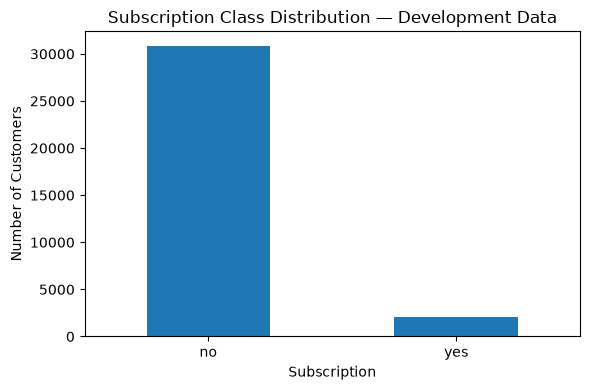

In [ ]:
ax = dev_df["y"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

ax.set_title("Subscription Class Distribution — Development Data")
ax.set_xlabel("Subscription")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
def category_subscription_summary(data, column):
    summary = (
        data.groupby(column)
        .agg(
            customers=("y", "size"),
            subscribers=("y", lambda values: (values == "yes").sum())
        )
    )

    summary["subscription_rate"] = (
        summary["subscribers"] / summary["customers"]
    )

    return summary.sort_values(
        "subscription_rate",
        ascending=False
    )

In [21]:
poutcome_summary = category_subscription_summary(
    dev_df,
    "poutcome"
)

poutcome_summary

,customers,subscribers,subscription_rate
poutcome,,,
success,168,63,0.375000
nonexistent,30675,1912,0.062331
failure,2107,125,0.059326


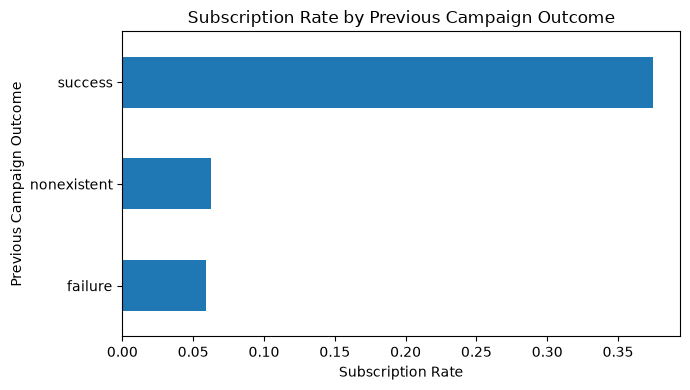

In [22]:
ax = (
    poutcome_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(7, 4)
    )
)

ax.set_title("Subscription Rate by Previous Campaign Outcome")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Previous Campaign Outcome")

plt.tight_layout()
plt.show()

In [25]:
contact_summary = category_subscription_summary(
    dev_df,
    "contact"
)

contact_summary

,customers,subscribers,subscription_rate
contact,,,
cellular,18899,1521,0.080480
telephone,14051,579,0.041207


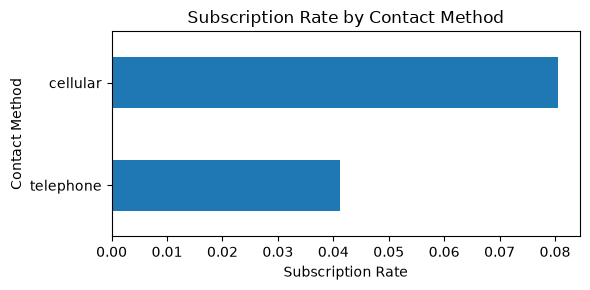

In [26]:
ax = (
    contact_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(6, 3)
    )
)

ax.set_title("Subscription Rate by Contact Method")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Contact Method")

plt.tight_layout()
plt.show()

In [27]:
month_summary = category_subscription_summary(
    dev_df,
    "month"
)

month_summary

,customers,subscribers,subscription_rate
month,,,
oct,67,42,0.626866
mar,282,126,0.446809
apr,2458,442,0.179821
dec,10,1,0.100000
jul,6685,407,0.060883
nov,3616,190,0.052544
aug,5175,271,0.052367
jun,4374,188,0.042981
may,10283,433,0.042108


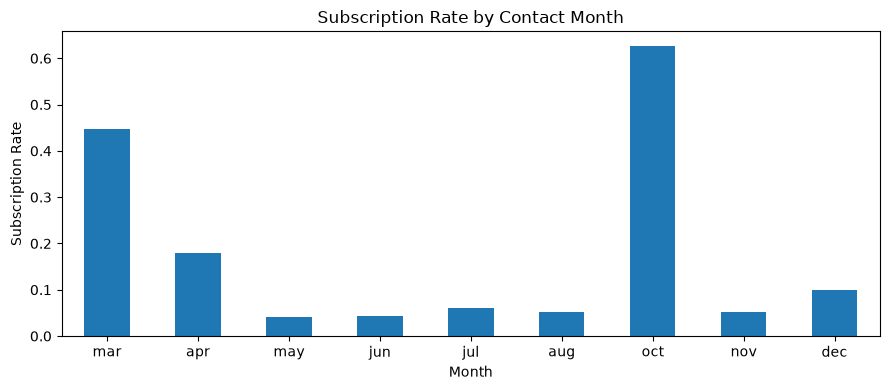

In [28]:
month_order = [
    "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct",
    "nov", "dec"
]

month_rates = (
    month_summary
    .reindex(month_order)
    ["subscription_rate"]
    .dropna()
)

ax = month_rates.plot(
    kind="bar",
    figsize=(9, 4)
)

ax.set_title("Subscription Rate by Contact Month")
ax.set_xlabel("Month")
ax.set_ylabel("Subscription Rate")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
job_summary = category_subscription_summary(
    dev_df,
    "job"
)

job_summary

,customers,subscribers,subscription_rate
job,,,
student,347,60,0.172911
retired,990,113,0.114141
self-employed,1156,81,0.070069
admin.,8040,558,0.069403
management,2400,159,0.066250
technician,5577,353,0.063296
entrepreneur,1261,79,0.062649
unemployed,749,43,0.057410
unknown,266,15,0.056391


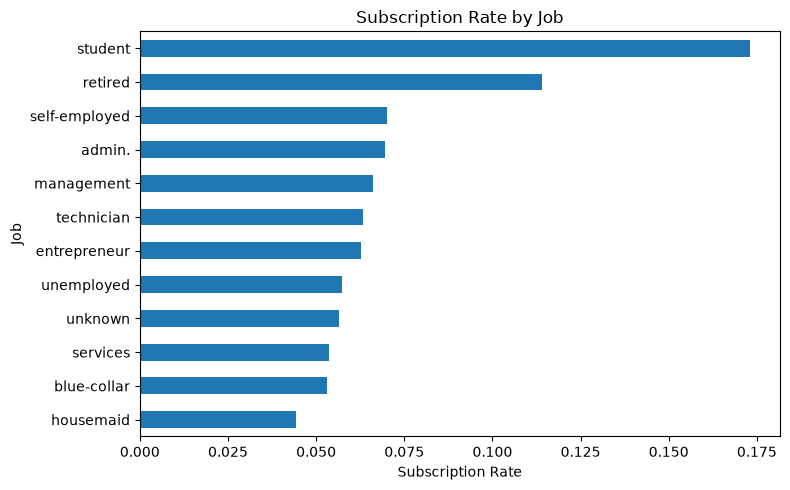

In [30]:
ax = (
    job_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8, 5)
    )
)

ax.set_title("Subscription Rate by Job")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Job")

plt.tight_layout()
plt.show()

In [31]:
default_summary = category_subscription_summary(
    dev_df,
    "default"
)

default_summary

,customers,subscribers,subscription_rate
default,,,
no,24930,1753,0.070317
unknown,8017,347,0.043283
yes,3,0,0.000000


In [32]:
approved_numeric_features = (
    dev_df[FEATURES]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

approved_numeric_features

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [33]:
numeric_medians_by_target = (
    dev_df.groupby("y")[approved_numeric_features]
    .median()
    .T
)

numeric_medians_by_target

y,no,yes
age,39.000,37.000
campaign,2.000,2.000
pdays,999.000,999.000
previous,0.000,0.000
emp.var.rate,1.100,1.100
cons.price.idx,93.918,93.444
cons.conf.idx,-41.800,-42.700
euribor3m,4.864,4.857
nr.employed,5195.800,5195.800


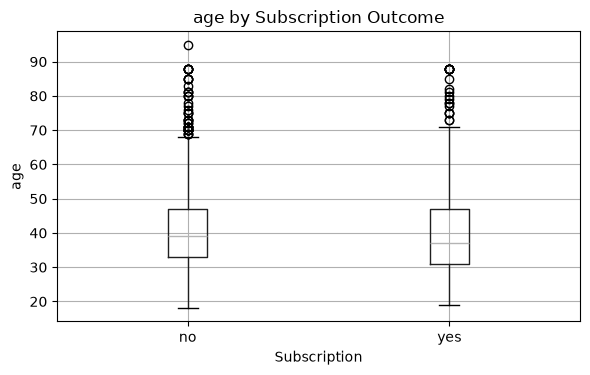

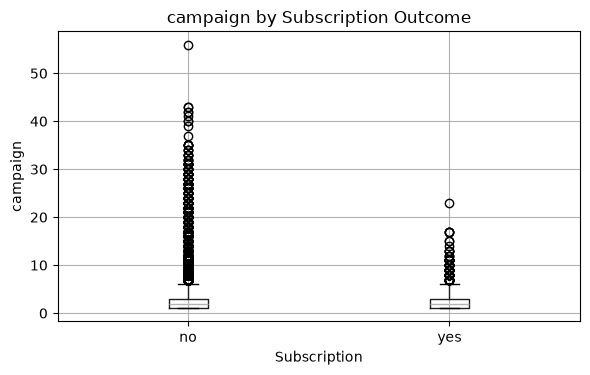

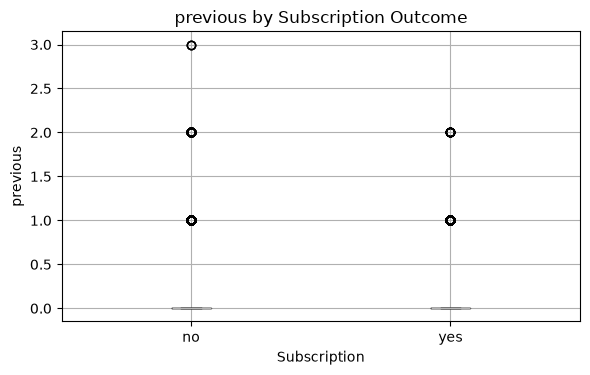

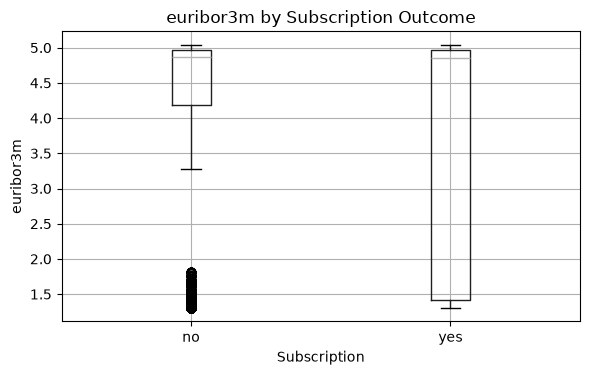

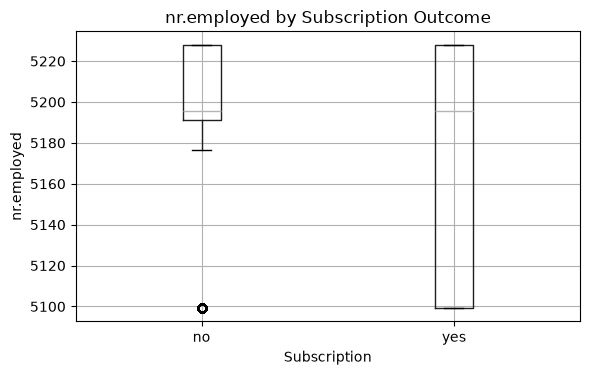

In [34]:
selected_numeric_features = [
    "age",
    "campaign",
    "previous",
    "euribor3m",
    "nr.employed"
]

for column in selected_numeric_features:
    ax = dev_df.boxplot(
        column=column,
        by="y",
        figsize=(6, 4)
    )

    ax.set_title(f"{column} by Subscription Outcome")
    ax.set_xlabel("Subscription")
    ax.set_ylabel(column)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [35]:
numeric_correlation = (
    dev_df[approved_numeric_features]
    .corr()
)

numeric_correlation.round(2)

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.00,0.02,-0.01,0.00,0.03,0.00,0.07,0.04,0.03
campaign,0.02,1.00,0.02,-0.07,0.14,0.14,0.03,0.12,0.14
pdays,-0.01,0.02,1.00,-0.28,0.13,0.10,0.10,0.13,0.12
previous,0.00,-0.07,-0.28,1.00,-0.44,-0.37,-0.31,-0.43,-0.39
emp.var.rate,0.03,0.14,0.13,-0.44,1.00,0.78,0.69,0.98,0.95
cons.price.idx,0.00,0.14,0.10,-0.37,0.78,1.00,0.37,0.74,0.66
cons.conf.idx,0.07,0.03,0.10,-0.31,0.69,0.37,1.00,0.72,0.55
euribor3m,0.04,0.12,0.13,-0.43,0.98,0.74,0.72,1.00,0.95
nr.employed,0.03,0.14,0.12,-0.39,0.95,0.66,0.55,0.95,1.00


In [36]:
upper_triangle = numeric_correlation.where(
    np.triu(
        np.ones(numeric_correlation.shape),
        k=1
    ).astype(bool)
)

strongest_correlations = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
    .head(10)
)

strongest_correlations.to_frame("correlation")

correlation
emp.var.rate   euribor3m          0.977621
euribor3m      nr.employed        0.951532
emp.var.rate   nr.employed        0.946403
               cons.price.idx     0.780208
cons.price.idx euribor3m          0.735253
cons.conf.idx  euribor3m          0.716260
emp.var.rate   cons.conf.idx      0.688109
cons.price.idx nr.employed        0.662134
cons.conf.idx  nr.employed        0.549268
previous       emp.var.rate      -0.441295

In [39]:
previous_contact_summary = (
    dev_df
    .assign(
        had_previous_contacts=lambda data:
            data["previous"] > 0
    )
    .groupby("had_previous_contacts")
    .agg(
        customers=("y", "size"),
        subscribers=("y", lambda values: (values == "yes").sum())
    )
)

previous_contact_summary["subscription_rate"] = (
    previous_contact_summary["subscribers"]
    / previous_contact_summary["customers"]
)

previous_contact_summary

,customers,subscribers,subscription_rate
had_previous_contacts,,,
False,30675,1912,0.062331
True,2275,188,0.082637


In [40]:
pd.crosstab(
    dev_df["previous"] > 0,
    dev_df["pdays"] == 999,
    rownames=["Previous contacts > 0"],
    colnames=["pdays = 999"]
)

pdays = 999,False,True
Previous contacts > 0,,
False,0,30675
True,174,2101


### EDA Findings

The exploratory analysis revealed several patterns that will guide the modeling stage:

- The development dataset is strongly imbalanced, with 2,100 subscribers out of 32,950 observations (approximately 6.37% positive cases). This reinforces the decision to avoid accuracy as the primary model-selection metric.

- Previous campaign outcome shows a strong descriptive relationship with subscription. Customers whose previous campaign outcome was `success` had a subscription rate of approximately 37.5%, compared with around 6% for `failure` and `nonexistent`. However, the successful-outcome group contains only 168 development observations, so this result should be interpreted cautiously.

- Customers contacted through `cellular` communication had a higher observed subscription rate (approximately 8.05%) than customers contacted by `telephone` (approximately 4.12%).

- Subscription rates varied substantially across contact months. Some months, particularly March and October, showed high observed rates, but several of these groups contain relatively few observations. These differences may also reflect changing campaign or economic conditions over time and should not be interpreted as causal effects of the month itself.

- Student and retired customer groups showed relatively high observed subscription rates compared with several other job categories. These results are descriptive associations and do not imply that occupation causes subscription behavior.

- The `default = yes` category contains only three observations in the development data and therefore provides insufficient evidence for meaningful conclusions about that category.

- Median values of several numerical variables are similar across the two target classes, suggesting that simple univariate numerical differences alone may not provide strong class separation.

- Several economic indicators are highly correlated. In particular, `emp.var.rate` and `euribor3m`, `euribor3m` and `nr.employed`, and `emp.var.rate` and `nr.employed` show correlations above 0.94. This will be considered when interpreting models, especially linear-model coefficients.

- Using `previous > 0` as the indicator of previous campaign contact, customers with previous contacts had an observed subscription rate of approximately 8.26%, compared with 6.23% for customers without previous contacts.

- The special value `pdays = 999` should not be interpreted as a simple binary indicator of whether a customer had previous contact. In the development data, 2,101 customers have `previous > 0` while also having `pdays = 999`. Its treatment will therefore be considered carefully during preprocessing.

These observations are exploratory associations only. No feature will be removed or retained solely because of these univariate patterns, and no causal conclusions are drawn from the analysis.

## 6. Data Cleaning and Preprocessing

The preprocessing strategy is designed to remain reproducible and compatible with cross-validation.

### Cleaning Decisions

- The leakage feature `duration` will not be included in the modeling feature set.
- The explicit `unknown` values in categorical variables will be retained as their own category rather than being treated as conventional missing values.
- Exact duplicate rows will be retained. Only a very small number were identified, and the dataset does not provide a unique customer or contact identifier that would allow them to be confidently classified as erroneous duplicate records.
- `pdays` will initially be treated as a categorical feature. The value `999` is a special sentinel value and does not behave like a normal numerical distance, so treating the entire variable as categorical avoids imposing an inappropriate linear numerical relationship.

### Transformation Strategy

Numerical variables will be standardized using `StandardScaler`.

Categorical variables will be encoded using one-hot encoding. Unknown categories encountered during validation or testing will be ignored rather than causing transformation errors.

All transformations will be placed inside a scikit-learn preprocessing pipeline so that preprocessing can later be fitted independently within each cross-validation fold.

In [41]:
X_dev = dev_df[FEATURES].copy()

y_dev = (
    dev_df[TARGET]
    .map({
        "no": 0,
        "yes": 1
    })
)

print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)

print("\nTarget mapping:")
print(y_dev.value_counts())

X_dev shape: (32950, 19)
y_dev shape: (32950,)

Target mapping:
y
0    30850
1     2100
Name: count, dtype: int64


In [42]:
print("Missing target values:", y_dev.isna().sum())

print(
    "duration in modeling features:",
    "duration" in X_dev.columns
)

print(
    "Target in modeling features:",
    TARGET in X_dev.columns
)

Missing target values: 0
duration in modeling features: False
Target in modeling features: False


In [43]:
NUMERIC_FEATURES = [
    "age",
    "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

CATEGORICAL_FEATURES = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
    "pdays"
]

print("Numerical features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print(
    "Total modeling features:",
    len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)
)

Numerical features: 8
Categorical features: 11
Total modeling features: 19


In [44]:
defined_features = set(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES
)

expected_features = set(FEATURES)

print(
    "Missing from preprocessing:",
    expected_features - defined_features
)

print(
    "Unexpected preprocessing features:",
    defined_features - expected_features
)

print(
    "Duplicated between feature groups:",
    set(NUMERIC_FEATURES).intersection(
        CATEGORICAL_FEATURES
    )
)

Missing from preprocessing: set()
Unexpected preprocessing features: set()
Duplicated between feature groups: set()


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [46]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [47]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categor

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [49]:
from sklearn.base import clone

preview_preprocessor = clone(preprocessor)

X_dev_transformed = (
    preview_preprocessor
    .fit_transform(X_dev)
)

print(
    "Original shape:",
    X_dev.shape
)

print(
    "Transformed shape:",
    X_dev_transformed.shape
)

Original shape: (32950, 19)
Transformed shape: (32950, 74)


In [50]:
transformed_feature_names = (
    preview_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

print("\nFirst 25 transformed features:")

for feature in transformed_feature_names[:25]:
    print(feature)

Number of transformed features: 74

First 25 transformed features:
num__age
num__campaign
num__previous
num__emp.var.rate
num__cons.price.idx
num__cons.conf.idx
num__euribor3m
num__nr.employed
cat__job_admin.
cat__job_blue-collar
cat__job_entrepreneur
cat__job_housemaid
cat__job_management
cat__job_retired
cat__job_self-employed
cat__job_services
cat__job_student
cat__job_technician
cat__job_unemployed
cat__job_unknown
cat__marital_divorced
cat__marital_married
cat__marital_single
cat__marital_unknown
cat__education_basic.4y


In [51]:
print(
    "NaN values after transformation:",
    np.isnan(X_dev_transformed).sum()
)

NaN values after transformation: 0


### Cross-Validation Safety

The fitted preprocessing object above is used only as a structural sanity check to verify that the transformations run successfully.

The transformed development matrix produced here will **not** be used directly for model comparison.

During modeling, the unfitted `preprocessor` will be placed inside a full scikit-learn `Pipeline` together with each estimator. This ensures that scaling and categorical encoding are learned separately from the training portion of each cross-validation split rather than from the entire development dataset.

The held-out test set has not been used to fit or inspect the preprocessing transformations.

### Preprocessing Decisions Summary

The final preprocessing design currently uses:

- **19 input features** after excluding `duration`.
- **8 numerical features**, standardized using `StandardScaler`.
- **11 categorical features**, encoded using `OneHotEncoder`.
- `unknown` values retained as explicit categories.
- `pdays` treated as categorical because of its special sentinel value and non-standard numerical semantics.
- Exact duplicate observations retained because there is insufficient evidence that they represent erroneous duplicate records.
- No conventional missing-value imputation is required.
- Preprocessing will be fitted inside each cross-validation fold through a complete model pipeline.

These decisions may be revisited only if later model diagnostics provide a clear, documented reason.

## 7. Baseline Model

Before training any predictive model, a simple baseline is established.

A `DummyClassifier` using the training-class prior will be used. This model does not learn relationships between customer features and subscription outcomes. Instead, it provides a reference level that the real machine-learning models must outperform.

The baseline will be evaluated using the same time-aware cross-validation folds and the same metrics that will later be used for all candidate models.

Because the positive-class prevalence changes across time periods, the validation positive rate will also be reported alongside Average Precision.

In [52]:
from sklearn.model_selection import TimeSeriesSplit

time_cv = TimeSeriesSplit(n_splits=5)

CV_SPLITS = list(
    time_cv.split(X_dev)
)

print("Number of CV folds:", len(CV_SPLITS))

Number of CV folds: 5


In [53]:
fold_overview = []

for fold_number, (train_idx, validation_idx) in enumerate(
    CV_SPLITS,
    start=1
):
    fold_overview.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "validation_rows": len(validation_idx),
        "train_positive_rate": y_dev.iloc[train_idx].mean(),
        "validation_positive_rate": y_dev.iloc[validation_idx].mean()
    })

fold_overview = pd.DataFrame(fold_overview)

fold_overview

,fold,train_rows,validation_rows,train_positive_rate,validation_positive_rate
0,1,5495,5491,0.029299,0.038973
1,2,10986,5491,0.034134,0.060280
2,3,16477,5491,0.042848,0.059188
3,4,21968,5491,0.046932,0.054453
4,5,27459,5491,0.048436,0.140229


In [54]:
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "accuracy": "accuracy"
}

In [55]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior"
            )
        )
    ]
)

dummy_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [56]:
from sklearn.model_selection import cross_validate

dummy_cv_raw = cross_validate(
    estimator=dummy_pipeline,
    X=X_dev,
    y=y_dev,
    cv=CV_SPLITS,
    scoring=SCORING,
    return_train_score=False
)

In [58]:
dummy_cv_raw.keys()

dict_keys(['fit_time', 'score_time', 'test_average_precision', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy'])

In [59]:
dummy_cv_results = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),

    "validation_positive_rate":
        fold_overview["validation_positive_rate"],

    "average_precision":
        dummy_cv_raw["test_average_precision"],

    "roc_auc":
        dummy_cv_raw["test_roc_auc"],

    "precision":
        dummy_cv_raw["test_precision"],

    "recall":
        dummy_cv_raw["test_recall"],

    "f1":
        dummy_cv_raw["test_f1"],

    "accuracy":
        dummy_cv_raw["test_accuracy"]
})

dummy_cv_results

,fold,validation_positive_rate,average_precision,roc_auc,precision,recall,f1,accuracy
0,1,0.038973,0.038973,0.5,0.0,0.0,0.0,0.961027
1,2,0.060280,0.060280,0.5,0.0,0.0,0.0,0.939720
2,3,0.059188,0.059188,0.5,0.0,0.0,0.0,0.940812
3,4,0.054453,0.054453,0.5,0.0,0.0,0.0,0.945547
4,5,0.140229,0.140229,0.5,0.0,0.0,0.0,0.859771


In [60]:
baseline_metrics = [
    "average_precision",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "accuracy"
]

dummy_summary = (
    dummy_cv_results[baseline_metrics]
    .agg(["mean", "std"])
    .T
)

dummy_summary

,mean,std
average_precision,0.070625,0.039831
roc_auc,0.500000,0.000000
precision,0.000000,0.000000
recall,0.000000,0.000000
f1,0.000000,0.000000
accuracy,0.929375,0.039831


In [61]:
BASELINE_AP = dummy_cv_results[
    "average_precision"
].mean()

print(
    "Mean baseline Average Precision:",
    round(BASELINE_AP, 4)
)

Mean baseline Average Precision: 0.0706


In [62]:
baseline_comparison = dummy_cv_results[
    [
        "fold",
        "validation_positive_rate",
        "average_precision"
    ]
].copy()

baseline_comparison

,fold,validation_positive_rate,average_precision
0,1,0.038973,0.038973
1,2,0.060280,0.060280
2,3,0.059188,0.059188
3,4,0.054453,0.054453
4,5,0.140229,0.140229


### Baseline Interpretation

The `DummyClassifier` provides a no-skill reference for model evaluation.

Across the five time-aware validation folds, the baseline achieved a mean Average Precision of approximately **0.071** and a ROC-AUC of **0.50**, indicating no ability to distinguish subscribers from non-subscribers.

At the default classification threshold, the dummy model predicted no positive cases, resulting in:

- Precision = 0
- Recall = 0
- F1-score = 0

Despite this, the model achieved a mean accuracy of approximately **92.9%** because the majority of customers did not subscribe. This demonstrates why accuracy is misleading for this imbalanced classification problem.

Average Precision closely matched the positive-class prevalence within each validation fold, as expected from a model that provides no useful ranking information.

The validation positive rate also changed substantially across time. In particular, the final validation fold contained approximately **14.0%** subscribers, compared with roughly **4–6%** in the earlier folds. This indicates temporal variation in the target distribution and reinforces the use of time-aware validation.

Future models must therefore outperform the no-skill Average Precision baseline while also being evaluated for consistency across different time periods.

## 8. Model 1 — Logistic Regression

Logistic Regression is used as the first real predictive model.

It provides a relatively interpretable linear baseline for binary classification and allows us to test whether the available customer, campaign, historical, and economic features contain predictive signal beyond the no-skill baseline.

The model will use the same preprocessing pipeline, time-ordered cross-validation folds, and evaluation metrics used for the dummy baseline.

No hyperparameter tuning will be performed at this stage. The initial model will use standard regularized Logistic Regression so that it can later be compared fairly with a different model family.

In [63]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [64]:
logistic_cv_raw = cross_validate(
    estimator=logistic_pipeline,
    X=X_dev,
    y=y_dev,
    cv=CV_SPLITS,
    scoring=SCORING,
    return_train_score=False
)

In [65]:
logistic_cv_results = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),

    "validation_positive_rate":
        fold_overview["validation_positive_rate"],

    "average_precision":
        logistic_cv_raw["test_average_precision"],

    "roc_auc":
        logistic_cv_raw["test_roc_auc"],

    "precision":
        logistic_cv_raw["test_precision"],

    "recall":
        logistic_cv_raw["test_recall"],

    "f1":
        logistic_cv_raw["test_f1"],

    "accuracy":
        logistic_cv_raw["test_accuracy"]
})

logistic_cv_results

,fold,validation_positive_rate,average_precision,roc_auc,precision,recall,f1,accuracy
0,1,0.038973,0.040013,0.529286,0.04042,0.359813,0.072676,0.642142
1,2,0.060280,0.071796,0.561041,0.00000,0.000000,0.000000,0.939720
2,3,0.059188,0.060793,0.494181,0.00000,0.000000,0.000000,0.940812
3,4,0.054453,0.053506,0.446536,0.00000,0.000000,0.000000,0.945547
4,5,0.140229,0.202630,0.654613,0.00000,0.000000,0.000000,0.859771


In [66]:
logistic_summary = (
    logistic_cv_results[baseline_metrics]
    .agg(["mean", "std"])
    .T
)

logistic_summary

,mean,std
average_precision,0.085748,0.066351
roc_auc,0.537132,0.078242
precision,0.008084,0.018076
recall,0.071963,0.160913
f1,0.014535,0.032502
accuracy,0.865598,0.129913


In [67]:
logistic_vs_baseline = pd.DataFrame({
    "fold":
        logistic_cv_results["fold"],

    "positive_rate":
        logistic_cv_results["validation_positive_rate"],

    "baseline_ap":
        dummy_cv_results["average_precision"],

    "logistic_ap":
        logistic_cv_results["average_precision"]
})

logistic_vs_baseline["ap_gain"] = (
    logistic_vs_baseline["logistic_ap"]
    - logistic_vs_baseline["baseline_ap"]
)

logistic_vs_baseline["ap_lift"] = (
    logistic_vs_baseline["logistic_ap"]
    / logistic_vs_baseline["baseline_ap"]
)

logistic_vs_baseline

,fold,positive_rate,baseline_ap,logistic_ap,ap_gain,ap_lift
0,1,0.038973,0.038973,0.040013,0.001040,1.026689
1,2,0.060280,0.060280,0.071796,0.011515,1.191031
2,3,0.059188,0.059188,0.060793,0.001606,1.027127
3,4,0.054453,0.054453,0.053506,-0.000947,0.982616
4,5,0.140229,0.140229,0.202630,0.062401,1.444990


In [68]:
print(
    "Mean Logistic AP:",
    round(
        logistic_cv_results[
            "average_precision"
        ].mean(),
        4
    )
)

print(
    "Mean Dummy AP:",
    round(BASELINE_AP, 4)
)

print(
    "Mean AP gain:",
    round(
        logistic_vs_baseline[
            "ap_gain"
        ].mean(),
        4
    )
)

print(
    "Mean AP lift over baseline:",
    round(
        logistic_vs_baseline[
            "ap_lift"
        ].mean(),
        2
    ),
    "x"
)

Mean Logistic AP: 0.0857
Mean Dummy AP: 0.0706
Mean AP gain: 0.0151
Mean AP lift over baseline: 1.13 x


In [69]:
logistic_vs_baseline["beats_baseline"] = (
    logistic_vs_baseline["logistic_ap"]
    > logistic_vs_baseline["baseline_ap"]
)

logistic_vs_baseline[
    [
        "fold",
        "baseline_ap",
        "logistic_ap",
        "ap_gain",
        "ap_lift",
        "beats_baseline"
    ]
]

,fold,baseline_ap,logistic_ap,ap_gain,ap_lift,beats_baseline
0,1,0.038973,0.040013,0.001040,1.026689,True
1,2,0.060280,0.071796,0.011515,1.191031,True
2,3,0.059188,0.060793,0.001606,1.027127,True
3,4,0.054453,0.053506,-0.000947,0.982616,False
4,5,0.140229,0.202630,0.062401,1.444990,True


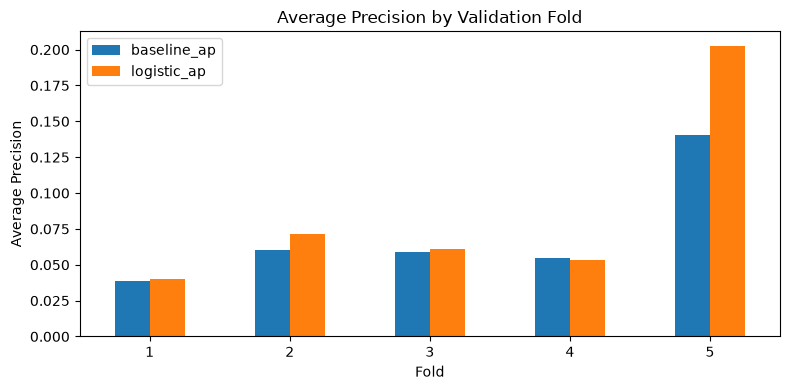

In [70]:
comparison_plot = (
    logistic_vs_baseline
    .set_index("fold")[
        [
            "baseline_ap",
            "logistic_ap"
        ]
    ]
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_title(
    "Average Precision by Validation Fold"
)

ax.set_xlabel("Fold")
ax.set_ylabel("Average Precision")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [71]:
logistic_classification_metrics = (
    logistic_cv_results[
        [
            "fold",
            "precision",
            "recall",
            "f1",
            "accuracy"
        ]
    ]
)

logistic_classification_metrics

,fold,precision,recall,f1,accuracy
0,1,0.04042,0.359813,0.072676,0.642142
1,2,0.00000,0.000000,0.000000,0.939720
2,3,0.00000,0.000000,0.000000,0.940812
3,4,0.00000,0.000000,0.000000,0.945547
4,5,0.00000,0.000000,0.000000,0.859771


In [72]:
logistic_timing = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),
    "fit_time": logistic_cv_raw["fit_time"],
    "score_time": logistic_cv_raw["score_time"]
})

logistic_timing

,fold,fit_time,score_time
0,1,0.099074,0.172360
1,2,0.089973,0.082803
2,3,0.193300,0.094876
3,4,0.280902,0.100605
4,5,0.274423,0.082972


### Logistic Regression Interpretation

Logistic Regression provided only a modest improvement over the no-skill baseline.

Across the five time-ordered validation folds, the model achieved a mean Average Precision of approximately **0.086**, compared with **0.071** for the Dummy baseline. This corresponds to an average AP gain of approximately **0.015** and a mean lift of about **1.13×** over the baseline.

Performance was not consistent across time periods. Logistic Regression outperformed the Average Precision baseline in four of the five validation folds, but the improvement was very small in several folds and the model performed slightly worse than the baseline in Fold 4.

The strongest improvement occurred in Fold 5, where Average Precision increased from approximately **0.140** to **0.203** and ROC-AUC reached approximately **0.655**.

At the default classification threshold of 0.5, the model predicted no positive cases in four of the five folds, producing zero precision, recall, and F1-score in those periods. This indicates that the default decision threshold is not suitable for interpreting classification performance in the current imbalanced and temporally varying setting.

Fold 1 showed different behavior, achieving approximately **36% recall** but only **4% precision**, resulting in a large number of false-positive predictions and substantially lower accuracy.

Overall, Logistic Regression shows limited predictive signal but considerable variation across validation periods. The results suggest that temporal distribution changes and decision-threshold behavior are important considerations for this problem.

No threshold adjustment or Logistic Regression hyperparameter tuning will be performed yet. A second model family will first be evaluated using the same validation folds and metrics.

## 9. Model 2 — Random Forest

Random Forest is evaluated as the second model family.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions between features without requiring those relationships to be specified manually.

The model will use the same preprocessing strategy, time-ordered validation folds, and evaluation metrics used for the previous models.

No hyperparameter tuning or class-weight adjustment will be performed at this stage. The initial objective is to compare the untuned Random Forest against Logistic Regression and the no-skill baseline under the same evaluation conditions.

In [73]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [74]:
random_forest_cv_raw = cross_validate(
    estimator=random_forest_pipeline,
    X=X_dev,
    y=y_dev,
    cv=CV_SPLITS,
    scoring=SCORING,
    return_train_score=True
)

In [75]:
random_forest_cv_results = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),

    "validation_positive_rate":
        fold_overview["validation_positive_rate"],

    "average_precision":
        random_forest_cv_raw["test_average_precision"],

    "roc_auc":
        random_forest_cv_raw["test_roc_auc"],

    "precision":
        random_forest_cv_raw["test_precision"],

    "recall":
        random_forest_cv_raw["test_recall"],

    "f1":
        random_forest_cv_raw["test_f1"],

    "accuracy":
        random_forest_cv_raw["test_accuracy"]
})

random_forest_cv_results

,fold,validation_positive_rate,average_precision,roc_auc,precision,recall,f1,accuracy
0,1,0.038973,0.037118,0.482663,0.0,0.000000,0.000000,0.960117
1,2,0.060280,0.058884,0.484034,0.0,0.000000,0.000000,0.939720
2,3,0.059188,0.057624,0.474714,0.2,0.003077,0.006061,0.940266
3,4,0.054453,0.052102,0.483461,0.0,0.000000,0.000000,0.944090
4,5,0.140229,0.186518,0.590606,0.0,0.000000,0.000000,0.859771


In [76]:
random_forest_summary = (
    random_forest_cv_results[baseline_metrics]
    .agg(["mean", "std"])
    .T
)

random_forest_summary

,mean,std
average_precision,0.078449,0.061028
roc_auc,0.503095,0.049066
precision,0.040000,0.089443
recall,0.000615,0.001376
f1,0.001212,0.002710
accuracy,0.928793,0.039466


In [77]:
random_forest_vs_baseline = pd.DataFrame({
    "fold":
        random_forest_cv_results["fold"],

    "positive_rate":
        random_forest_cv_results["validation_positive_rate"],

    "baseline_ap":
        dummy_cv_results["average_precision"],

    "random_forest_ap":
        random_forest_cv_results["average_precision"]
})

random_forest_vs_baseline["ap_gain"] = (
    random_forest_vs_baseline["random_forest_ap"]
    - random_forest_vs_baseline["baseline_ap"]
)

random_forest_vs_baseline["ap_lift"] = (
    random_forest_vs_baseline["random_forest_ap"]
    / random_forest_vs_baseline["baseline_ap"]
)

random_forest_vs_baseline["beats_baseline"] = (
    random_forest_vs_baseline["random_forest_ap"]
    > random_forest_vs_baseline["baseline_ap"]
)

random_forest_vs_baseline

,fold,positive_rate,baseline_ap,random_forest_ap,ap_gain,ap_lift,beats_baseline
0,1,0.038973,0.038973,0.037118,-0.001855,0.952396,False
1,2,0.060280,0.060280,0.058884,-0.001396,0.976838,False
2,3,0.059188,0.059188,0.057624,-0.001564,0.973577,False
3,4,0.054453,0.054453,0.052102,-0.002350,0.956836,False
4,5,0.140229,0.140229,0.186518,0.046288,1.330089,True


In [78]:
model_ap_comparison = pd.DataFrame({
    "fold":
        logistic_cv_results["fold"],

    "baseline_ap":
        dummy_cv_results["average_precision"],

    "logistic_ap":
        logistic_cv_results["average_precision"],

    "random_forest_ap":
        random_forest_cv_results["average_precision"]
})

model_ap_comparison

,fold,baseline_ap,logistic_ap,random_forest_ap
0,1,0.038973,0.040013,0.037118
1,2,0.060280,0.071796,0.058884
2,3,0.059188,0.060793,0.057624
3,4,0.054453,0.053506,0.052102
4,5,0.140229,0.202630,0.186518


In [79]:
model_ap_comparison["rf_minus_logistic"] = (
    model_ap_comparison["random_forest_ap"]
    - model_ap_comparison["logistic_ap"]
)

model_ap_comparison["better_real_model"] = np.where(
    model_ap_comparison["random_forest_ap"]
    > model_ap_comparison["logistic_ap"],
    "Random Forest",
    "Logistic Regression"
)

model_ap_comparison

,fold,baseline_ap,logistic_ap,random_forest_ap,rf_minus_logistic,better_real_model
0,1,0.038973,0.040013,0.037118,-0.002895,Logistic Regression
1,2,0.060280,0.071796,0.058884,-0.012912,Logistic Regression
2,3,0.059188,0.060793,0.057624,-0.003169,Logistic Regression
3,4,0.054453,0.053506,0.052102,-0.001404,Logistic Regression
4,5,0.140229,0.202630,0.186518,-0.016112,Logistic Regression


In [80]:
RF_MEAN_AP = random_forest_cv_results[
    "average_precision"
].mean()

LOGISTIC_MEAN_AP = logistic_cv_results[
    "average_precision"
].mean()

print(
    "Mean Dummy AP:",
    round(BASELINE_AP, 4)
)

print(
    "Mean Logistic AP:",
    round(LOGISTIC_MEAN_AP, 4)
)

print(
    "Mean Random Forest AP:",
    round(RF_MEAN_AP, 4)
)

print(
    "RF AP gain over baseline:",
    round(
        RF_MEAN_AP - BASELINE_AP,
        4
    )
)

print(
    "RF AP gain over Logistic:",
    round(
        RF_MEAN_AP - LOGISTIC_MEAN_AP,
        4
    )
)

Mean Dummy AP: 0.0706
Mean Logistic AP: 0.0857
Mean Random Forest AP: 0.0784
RF AP gain over baseline: 0.0078
RF AP gain over Logistic: -0.0073


In [84]:
random_forest_generalization = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),

    "train_ap":
        random_forest_cv_raw["train_average_precision"],

    "validation_ap":
        random_forest_cv_raw["test_average_precision"]
})

random_forest_generalization["generalization_gap"] = (
    random_forest_generalization["train_ap"]
    - random_forest_generalization["validation_ap"]
)

random_forest_generalization

,fold,train_ap,validation_ap,generalization_gap
0,1,0.999619,0.037118,0.962501
1,2,0.999159,0.058884,0.940275
2,3,0.996641,0.057624,0.939017
3,4,0.994783,0.052102,0.942681
4,5,0.994559,0.186518,0.808042


In [81]:
random_forest_classification_metrics = (
    random_forest_cv_results[
        [
            "fold",
            "precision",
            "recall",
            "f1",
            "accuracy"
        ]
    ]
)

random_forest_classification_metrics

,fold,precision,recall,f1,accuracy
0,1,0.0,0.000000,0.000000,0.960117
1,2,0.0,0.000000,0.000000,0.939720
2,3,0.2,0.003077,0.006061,0.940266
3,4,0.0,0.000000,0.000000,0.944090
4,5,0.0,0.000000,0.000000,0.859771


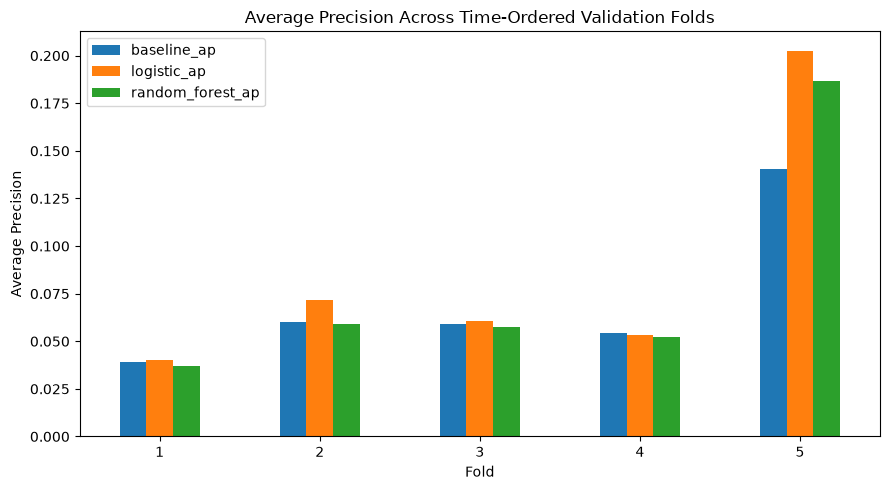

In [82]:
comparison_plot = (
    model_ap_comparison
    .set_index("fold")[
        [
            "baseline_ap",
            "logistic_ap",
            "random_forest_ap"
        ]
    ]
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Average Precision Across Time-Ordered Validation Folds"
)

ax.set_xlabel("Fold")
ax.set_ylabel("Average Precision")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [83]:
model_summary = pd.DataFrame({
    "Dummy": {
        "mean_ap":
            dummy_cv_results["average_precision"].mean(),

        "std_ap":
            dummy_cv_results["average_precision"].std(),

        "mean_roc_auc":
            dummy_cv_results["roc_auc"].mean()
    },

    "Logistic Regression": {
        "mean_ap":
            logistic_cv_results["average_precision"].mean(),

        "std_ap":
            logistic_cv_results["average_precision"].std(),

        "mean_roc_auc":
            logistic_cv_results["roc_auc"].mean()
    },

    "Random Forest": {
        "mean_ap":
            random_forest_cv_results["average_precision"].mean(),

        "std_ap":
            random_forest_cv_results["average_precision"].std(),

        "mean_roc_auc":
            random_forest_cv_results["roc_auc"].mean()
    }
}).T

model_summary

,mean_ap,std_ap,mean_roc_auc
Dummy,0.070625,0.039831,0.500000
Logistic Regression,0.085748,0.066351,0.537132
Random Forest,0.078449,0.061028,0.503095


### Random Forest Interpretation

The untuned Random Forest did not improve upon Logistic Regression under the time-ordered validation strategy.

Across the five validation folds, Random Forest achieved a mean Average Precision of approximately **0.078**, compared with **0.086** for Logistic Regression and **0.071** for the no-skill baseline.

Random Forest underperformed the no-skill Average Precision baseline in four of the five validation periods and exceeded it only in Fold 5.

Logistic Regression achieved higher Average Precision than Random Forest in every validation fold, indicating that the initial Random Forest does not provide a stronger predictive model for this dataset under the current preprocessing and evaluation design.

Mean ROC-AUC for Random Forest was approximately **0.503**, which is close to random ranking performance. The model performed below 0.5 ROC-AUC in the first four folds and improved only in the final validation period.

At the default classification threshold of 0.5, Random Forest identified almost no positive cases. Recall was zero in four folds and approximately 0.003 in the remaining fold. Therefore, the high mean accuracy of approximately **92.9%** should not be interpreted as useful classification performance.

The training-versus-validation comparison provides further evidence of substantial overfitting. Training Average Precision was approximately 0.995–1.000 across all folds, while validation Average Precision ranged from approximately 0.037 to 0.187. The resulting generalization gaps ranged from approximately 0.81 to 0.96.

This indicates that the default Random Forest fits the historical training observations extremely well but does not generalize reliably to subsequent time periods. This further supports selecting Logistic Regression as the stronger model family for tuning.

## 10. Hyperparameter Tuning — Logistic Regression

Logistic Regression was selected for tuning because it achieved higher Average Precision than Random Forest in every validation fold and showed substantially better generalization.

Hyperparameter tuning will focus on:

- `C`, which controls the strength of regularization.
- `class_weight`, to evaluate whether compensating for class imbalance improves ranking performance.

The same time-ordered cross-validation folds will be used during tuning.

Average Precision remains the primary optimization metric. The held-out test set will not be used during hyperparameter selection.

In [85]:
logistic_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

logistic_tuning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [86]:
LOGISTIC_PARAM_GRID = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

LOGISTIC_PARAM_GRID

{'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
 'model__class_weight': [None, 'balanced']}

In [87]:
from sklearn.model_selection import GridSearchCV

logistic_grid_search = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=LOGISTIC_PARAM_GRID,
    scoring=SCORING,
    refit="average_precision",
    cv=CV_SPLITS,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid_search.fit(
    X_dev,
    y_dev
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'average_precision': 'average_precision', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies

In [88]:
print(
    "Best parameters:",
    logistic_grid_search.best_params_
)

print(
    "Best cross-validated Average Precision:",
    round(
        logistic_grid_search.best_score_,
        4
    )
)

Best parameters: {'model__C': 10.0, 'model__class_weight': None}
Best cross-validated Average Precision: 0.086


In [89]:
logistic_tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

tuning_columns = [
    "param_model__C",
    "param_model__class_weight",
    "mean_train_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "rank_test_average_precision"
]

logistic_tuning_summary = (
    logistic_tuning_results[
        tuning_columns
    ]
    .sort_values(
        "rank_test_average_precision"
    )
)

logistic_tuning_summary

,param_model__C,param_model__class_weight,mean_train_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_average_precision
8,10.000,NaN,0.072281,0.086027,0.059974,0.537782,0.008084,0.071963,0.014535,1
10,100.000,NaN,0.072656,0.085916,0.059726,0.537683,0.008084,0.071963,0.014535,2
6,1.000,NaN,0.072238,0.085748,0.059347,0.537132,0.008084,0.071963,0.014535,3
0,0.001,NaN,0.057935,0.081746,0.058153,0.522282,0.000000,0.000000,0.000000,4
4,0.100,NaN,0.071432,0.081719,0.058715,0.520690,0.008084,0.071963,0.014535,5
5,0.100,balanced,0.069167,0.081362,0.058630,0.521173,0.055394,0.604563,0.080418,6
1,0.001,balanced,0.066537,0.080860,0.055951,0.526732,0.048393,0.592975,0.076669,7
9,10.000,balanced,0.069199,0.080757,0.056071,0.518228,0.055108,0.600764,0.079891,8
11,100.000,balanced,0.069246,0.080630,0.055852,0.518173,0.054130,0.601433,0.079959,9
7,1.000,balanced,0.069112,0.080612,0.055949,0.518870,0.053890,0.602314,0.080006,10


In [90]:
logistic_tuning_summary.head(5)

,param_model__C,param_model__class_weight,mean_train_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_average_precision
8,10.000,NaN,0.072281,0.086027,0.059974,0.537782,0.008084,0.071963,0.014535,1
10,100.000,NaN,0.072656,0.085916,0.059726,0.537683,0.008084,0.071963,0.014535,2
6,1.000,NaN,0.072238,0.085748,0.059347,0.537132,0.008084,0.071963,0.014535,3
0,0.001,NaN,0.057935,0.081746,0.058153,0.522282,0.000000,0.000000,0.000000,4
4,0.100,NaN,0.071432,0.081719,0.058715,0.520690,0.008084,0.071963,0.014535,5


In [91]:
UNTUNED_LOGISTIC_AP = (
    logistic_cv_results[
        "average_precision"
    ].mean()
)

TUNED_LOGISTIC_AP = (
    logistic_grid_search.best_score_
)

print(
    "Untuned Logistic mean AP:",
    round(
        UNTUNED_LOGISTIC_AP,
        4
    )
)

print(
    "Tuned Logistic mean AP:",
    round(
        TUNED_LOGISTIC_AP,
        4
    )
)

print(
    "AP improvement after tuning:",
    round(
        TUNED_LOGISTIC_AP
        - UNTUNED_LOGISTIC_AP,
        4
    )
)

Untuned Logistic mean AP: 0.0857
Tuned Logistic mean AP: 0.086
AP improvement after tuning: 0.0003


In [92]:
best_index = (
    logistic_grid_search.best_index_
)

best_tuned_fold_results = pd.DataFrame({
    "fold": range(
        1,
        len(CV_SPLITS) + 1
    ),

    "baseline_ap":
        dummy_cv_results[
            "average_precision"
        ].values,

    "untuned_logistic_ap":
        logistic_cv_results[
            "average_precision"
        ].values,

    "tuned_logistic_ap": [
        logistic_tuning_results.loc[
            best_index,
            f"split{i}_test_average_precision"
        ]
        for i in range(len(CV_SPLITS))
    ]
})

best_tuned_fold_results

,fold,baseline_ap,untuned_logistic_ap,tuned_logistic_ap
0,1,0.038973,0.040013,0.039946
1,2,0.060280,0.071796,0.071822
2,3,0.059188,0.060793,0.060873
3,4,0.054453,0.053506,0.053328
4,5,0.140229,0.202630,0.204168


In [93]:
best_tuned_fold_results[
    "tuned_vs_untuned"
] = (
    best_tuned_fold_results[
        "tuned_logistic_ap"
    ]
    - best_tuned_fold_results[
        "untuned_logistic_ap"
    ]
)

best_tuned_fold_results[
    "tuned_vs_baseline"
] = (
    best_tuned_fold_results[
        "tuned_logistic_ap"
    ]
    - best_tuned_fold_results[
        "baseline_ap"
    ]
)

best_tuned_fold_results[
    "beats_baseline"
] = (
    best_tuned_fold_results[
        "tuned_logistic_ap"
    ]
    > best_tuned_fold_results[
        "baseline_ap"
    ]
)

best_tuned_fold_results

,fold,baseline_ap,untuned_logistic_ap,tuned_logistic_ap,tuned_vs_untuned,tuned_vs_baseline,beats_baseline
0,1,0.038973,0.040013,0.039946,-0.000067,0.000973,True
1,2,0.060280,0.071796,0.071822,0.000026,0.011542,True
2,3,0.059188,0.060793,0.060873,0.000080,0.001685,True
3,4,0.054453,0.053506,0.053328,-0.000178,-0.001125,False
4,5,0.140229,0.202630,0.204168,0.001538,0.063938,True


In [94]:
best_tuned_generalization = pd.DataFrame({
    "fold": range(
        1,
        len(CV_SPLITS) + 1
    ),

    "train_ap": [
        logistic_tuning_results.loc[
            best_index,
            f"split{i}_train_average_precision"
        ]
        for i in range(len(CV_SPLITS))
    ],

    "validation_ap": [
        logistic_tuning_results.loc[
            best_index,
            f"split{i}_test_average_precision"
        ]
        for i in range(len(CV_SPLITS))
    ]
})

best_tuned_generalization[
    "generalization_gap"
] = (
    best_tuned_generalization["train_ap"]
    - best_tuned_generalization[
        "validation_ap"
    ]
)

best_tuned_generalization

,fold,train_ap,validation_ap,generalization_gap
0,1,0.059410,0.039946,0.019464
1,2,0.054964,0.071822,-0.016859
2,3,0.074711,0.060873,0.013837
3,4,0.069654,0.053328,0.016326
4,5,0.102666,0.204168,-0.101502


In [95]:
best_logistic_pipeline = (
    logistic_grid_search.best_estimator_
)

best_logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

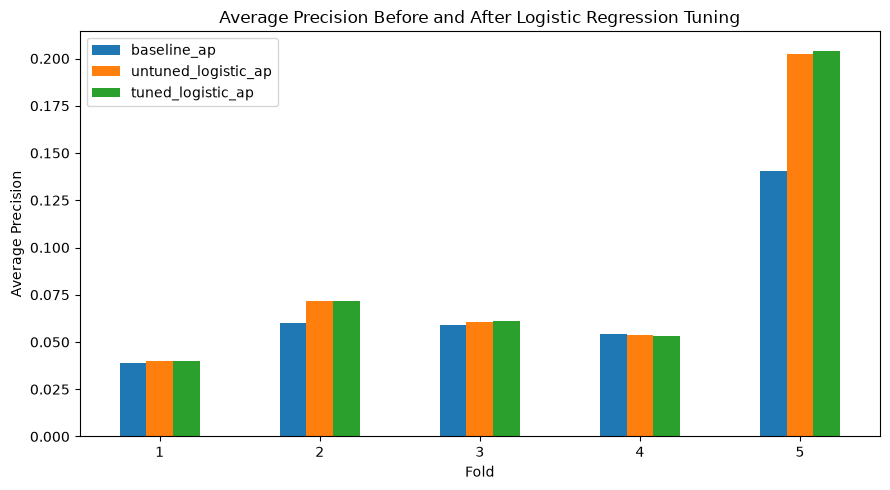

In [96]:
plot_data = (
    best_tuned_fold_results
    .set_index("fold")[
        [
            "baseline_ap",
            "untuned_logistic_ap",
            "tuned_logistic_ap"
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Average Precision Before and After Logistic Regression Tuning"
)

ax.set_xlabel("Fold")
ax.set_ylabel("Average Precision")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning Interpretation

Logistic Regression was tuned using the same time-ordered validation folds, with Average Precision as the optimization metric.

The best configuration used:

- `C = 10.0`
- `class_weight = None`

The tuned model achieved a mean cross-validated Average Precision of approximately **0.0860**, compared with approximately **0.0857** for the untuned Logistic Regression.

This represents an improvement of only about **0.0003**, indicating that hyperparameter tuning produced minimal improvement in ranking performance.

The tuned model remained above the no-skill baseline in four of the five validation periods but continued to perform slightly below the baseline in Fold 4. Therefore, tuning did not eliminate the temporal instability observed in the original Logistic Regression model.

Configurations using `class_weight="balanced"` substantially increased recall at the default classification threshold but achieved lower Average Precision. Because Average Precision was defined in advance as the primary model-selection metric, the unweighted configuration was retained.

Unlike the Random Forest, the tuned Logistic Regression did not show evidence of extreme overfitting. Training and validation Average Precision remained relatively close in most folds, although performance continued to vary across time periods.

Overall, Logistic Regression remains the strongest model family evaluated so far, but the very small improvement from tuning suggests that model performance is limited more by the available predictive signal and temporal distribution changes than by the selected regularization strength.

## 11. Threshold Analysis

Average Precision remains the primary metric for model evaluation because it evaluates ranking performance across decision thresholds.

However, the default classification threshold of 0.5 produced very poor recall during cross-validation. Therefore, threshold behavior will be investigated using development data only.

To avoid evaluating thresholds on predictions generated from the same observations used to fit the model, out-of-fold probabilities will be generated from the existing time-ordered validation folds.

Because no explicit campaign cost, outreach capacity, or business utility function is available, this project will not claim a business-optimal threshold.

Instead, the threshold that maximizes F1-score across the development out-of-fold predictions will be used as a neutral reporting threshold for later classification diagnostics.

The held-out test set remains untouched during this process.

In [97]:
from sklearn.base import clone

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

oof_parts = []

for fold_number, (train_idx, validation_idx) in enumerate(
    CV_SPLITS,
    start=1
):
    fold_model = clone(best_logistic_pipeline)

    fold_model.fit(
        X_dev.iloc[train_idx],
        y_dev.iloc[train_idx]
    )

    validation_probabilities = fold_model.predict_proba(
        X_dev.iloc[validation_idx]
    )[:, 1]

    fold_predictions = pd.DataFrame({
        "row_position": validation_idx,
        "fold": fold_number,
        "y_true": y_dev.iloc[validation_idx].to_numpy(),
        "y_prob": validation_probabilities
    })

    oof_parts.append(fold_predictions)

oof_predictions = (
    pd.concat(
        oof_parts,
        ignore_index=True
    )
    .sort_values("row_position")
    .reset_index(drop=True)
)

oof_predictions.head()

,row_position,fold,y_true,y_prob
0,5495,1,0,0.016655
1,5496,1,0,0.036759
2,5497,1,0,0.027421
3,5498,1,0,0.004080
4,5499,1,0,0.002013


In [98]:
expected_oof_rows = sum(
    len(validation_idx)
    for _, validation_idx in CV_SPLITS
)

print(
    "OOF rows:",
    len(oof_predictions)
)

print(
    "Expected OOF rows:",
    expected_oof_rows
)

print(
    "Unique validation positions:",
    oof_predictions["row_position"].nunique()
)

print(
    "Duplicate validation positions:",
    oof_predictions["row_position"].duplicated().sum()
)

print(
    "\nRows per fold:"
)

print(
    oof_predictions["fold"]
    .value_counts()
    .sort_index()
)

OOF rows: 27455
Expected OOF rows: 27455
Unique validation positions: 27455
Duplicate validation positions: 0

Rows per fold:
fold
1    5491
2    5491
3    5491
4    5491
5    5491
Name: count, dtype: int64


In [99]:
OOF_AP = average_precision_score(
    oof_predictions["y_true"],
    oof_predictions["y_prob"]
)

OOF_ROC_AUC = roc_auc_score(
    oof_predictions["y_true"],
    oof_predictions["y_prob"]
)

OOF_POSITIVE_RATE = (
    oof_predictions["y_true"].mean()
)

print(
    "OOF positive rate:",
    round(OOF_POSITIVE_RATE, 4)
)

print(
    "OOF Average Precision:",
    round(OOF_AP, 4)
)

print(
    "OOF ROC-AUC:",
    round(OOF_ROC_AUC, 4)
)

OOF positive rate: 0.0706
OOF Average Precision: 0.0565
OOF ROC-AUC: 0.4037


In [109]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        oof_predictions["y_true"],
        oof_predictions["y_prob"]
    )
)

threshold_precision = precision_values[:-1]
threshold_recall = recall_values[:-1]

threshold_f1 = np.divide(
    2 * threshold_precision * threshold_recall,
    threshold_precision + threshold_recall,
    out=np.zeros_like(threshold_precision),
    where=(threshold_precision + threshold_recall) != 0
)

best_threshold_index = int(
    np.argmax(threshold_f1)
)

REPORTING_THRESHOLD = float(
    thresholds[best_threshold_index]
)

print(
    "F1-maximizing reporting threshold:",
    round(REPORTING_THRESHOLD, 4)
)

print(
    "Precision at selected threshold:",
    round(
        threshold_precision[
            best_threshold_index
        ],
        4
    )
)

print(
    "Recall at selected threshold:",
    round(
        threshold_recall[
            best_threshold_index
        ],
        4
    )
)

print(
    "F1 at selected threshold:",
    round(
        threshold_f1[
            best_threshold_index
        ],
        4
    )
)

F1-maximizing reporting threshold: 0.0004
Precision at selected threshold: 0.0712
Recall at selected threshold: 0.9804
F1 at selected threshold: 0.1328


In [101]:
def evaluate_threshold(
    y_true,
    y_prob,
    threshold
):
    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": threshold,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "predicted_positive_rate":
            y_pred.mean(),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    }

In [102]:
candidate_thresholds = sorted(
    set([
        0.05,
        0.10,
        0.20,
        0.30,
        0.50,
        round(
            REPORTING_THRESHOLD,
            6
        )
    ])
)

threshold_results = pd.DataFrame([
    evaluate_threshold(
        oof_predictions["y_true"],
        oof_predictions["y_prob"],
        threshold
    )
    for threshold in candidate_thresholds
])

threshold_results

,threshold,precision,recall,f1,predicted_positive_rate,true_negative,false_positive,false_negative,true_positive
0,0.000431,0.071247,0.980402,0.132840,0.971845,735,24781,38,1901
1,0.050000,0.052533,0.461578,0.094330,0.620543,9374,16142,1044,895
2,0.100000,0.052673,0.137700,0.076199,0.184629,20714,4802,1672,267
3,0.200000,0.043032,0.045384,0.044177,0.074486,23559,1957,1851,88
4,0.300000,0.040881,0.040227,0.040551,0.069496,23686,1830,1861,78
5,0.500000,0.040420,0.039711,0.040062,0.069386,23688,1828,1862,77


In [103]:
threshold_comparison = pd.DataFrame([
    evaluate_threshold(
        oof_predictions["y_true"],
        oof_predictions["y_prob"],
        0.5
    ),
    evaluate_threshold(
        oof_predictions["y_true"],
        oof_predictions["y_prob"],
        REPORTING_THRESHOLD
    )
])

threshold_comparison.index = [
    "default_0.5",
    "development_reporting_threshold"
]

threshold_comparison

,threshold,precision,recall,f1,predicted_positive_rate,true_negative,false_positive,false_negative,true_positive
default_0.5,0.500000,0.040420,0.039711,0.040062,0.069386,23688,1828,1862,77
development_reporting_threshold,0.000431,0.071247,0.980402,0.132840,0.971845,735,24781,38,1901


In [104]:
fold_threshold_results = []

for fold_number, fold_data in (
    oof_predictions.groupby("fold")
):

    metrics = evaluate_threshold(
        fold_data["y_true"],
        fold_data["y_prob"],
        REPORTING_THRESHOLD
    )

    metrics["fold"] = fold_number
    metrics["actual_positive_rate"] = (
        fold_data["y_true"].mean()
    )

    fold_threshold_results.append(
        metrics
    )

fold_threshold_results = (
    pd.DataFrame(
        fold_threshold_results
    )
    [
        [
            "fold",
            "actual_positive_rate",
            "predicted_positive_rate",
            "precision",
            "recall",
            "f1",
            "false_positive",
            "false_negative",
            "true_positive"
        ]
    ]
)

fold_threshold_results

,fold,actual_positive_rate,predicted_positive_rate,precision,recall,f1,false_positive,false_negative,true_positive
0,1,0.038973,1.000000,0.038973,1.000000,0.075022,5277,0,214
1,2,0.060280,1.000000,0.060280,1.000000,0.113707,5160,0,331
2,3,0.059188,1.000000,0.059188,1.000000,0.111761,5166,0,325
3,4,0.054453,1.000000,0.054453,1.000000,0.103282,5192,0,299
4,5,0.140229,0.859224,0.155150,0.950649,0.266764,3986,38,732


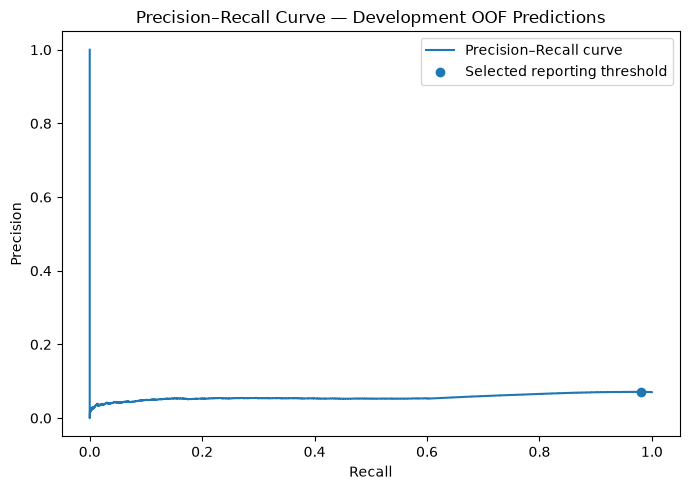

In [105]:
ax = plt.figure(
    figsize=(7, 5)
).gca()

ax.plot(
    recall_values,
    precision_values,
    label="Precision–Recall curve"
)

ax.scatter(
    threshold_recall[
        best_threshold_index
    ],
    threshold_precision[
        best_threshold_index
    ],
    label="Selected reporting threshold"
)

ax.set_title(
    "Precision–Recall Curve — Development OOF Predictions"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend()

plt.tight_layout()
plt.show()

In [106]:
def best_f1_threshold_from_probabilities(y_true, y_prob):
    precision_vals, recall_vals, threshold_vals = precision_recall_curve(
        y_true,
        y_prob
    )

    precision_t = precision_vals[:-1]
    recall_t = recall_vals[:-1]

    f1_t = np.divide(
        2 * precision_t * recall_t,
        precision_t + recall_t,
        out=np.zeros_like(precision_t),
        where=(precision_t + recall_t) != 0
    )

    best_idx = int(np.argmax(f1_t))

    return {
        "best_threshold": float(threshold_vals[best_idx]),
        "precision": float(precision_t[best_idx]),
        "recall": float(recall_t[best_idx]),
        "f1": float(f1_t[best_idx])
    }


fold_best_thresholds = []

for fold_number, fold_data in oof_predictions.groupby("fold"):
    result = best_f1_threshold_from_probabilities(
        fold_data["y_true"],
        fold_data["y_prob"]
    )

    result["fold"] = fold_number
    result["actual_positive_rate"] = fold_data["y_true"].mean()

    fold_best_thresholds.append(result)

fold_best_thresholds = pd.DataFrame(fold_best_thresholds)[
    [
        "fold",
        "actual_positive_rate",
        "best_threshold",
        "precision",
        "recall",
        "f1"
    ]
]

fold_best_thresholds

,fold,actual_positive_rate,best_threshold,precision,recall,f1
0,1,0.038973,0.083070,0.045731,0.668224,0.085603
1,2,0.060280,0.063224,0.074729,0.625378,0.133505
2,3,0.059188,0.020112,0.059408,0.975385,0.111994
3,4,0.054453,0.013768,0.054463,1.000000,0.103299
4,5,0.140229,0.001020,0.216424,0.657143,0.325611


In [107]:
fold_best_thresholds.describe()

,fold,actual_positive_rate,best_threshold,precision,recall,f1
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,0.070625,0.036239,0.090151,0.785226,0.152003
std,1.581139,0.039831,0.035095,0.071370,0.185698,0.098569
min,1.000000,0.038973,0.001020,0.045731,0.625378,0.085603
25%,2.000000,0.054453,0.013768,0.054463,0.657143,0.103299
50%,3.000000,0.059188,0.020112,0.059408,0.668224,0.111994
75%,4.000000,0.060280,0.063224,0.074729,0.975385,0.133505
max,5.000000,0.140229,0.083070,0.216424,1.000000,0.325611


In [108]:
median_fold_threshold = fold_best_thresholds["best_threshold"].median()

print("Median fold-level best threshold:", round(median_fold_threshold, 6))

Median fold-level best threshold: 0.020112


### Threshold Analysis Interpretation

Threshold analysis confirmed that the default classification threshold of 0.5 is poorly suited to the current imbalanced prediction problem.

At the default threshold, the model produced very low recall and F1-score, indicating that very few subscribers were identified.

A pooled F1-maximizing threshold from the combined development out-of-fold predictions was approximately `0.0004`. However, this threshold classified approximately 97% of development observations as positive and therefore does not represent a practical or stable operating threshold.

Fold-level analysis showed substantial threshold instability across time. The F1-maximizing thresholds ranged from approximately `0.083` in Fold 1 to approximately `0.001` in Fold 5.

The median fold-level threshold was approximately `0.020`, but this value is retained only as a descriptive reference and is not adopted as a final decision threshold.

The variation in threshold behavior indicates that predicted probability distributions change considerably across validation periods. A single fixed threshold selected from the development data therefore cannot be considered robust across time.

Some folds achieved high recall only by accepting very low precision. For example, Folds 3 and 4 achieved approximately 98–100% recall while precision remained around 5–6%. Without information about outreach costs, campaign capacity, or the relative business cost of false positives and false negatives, these trade-offs cannot be converted into a defensible business-optimal threshold.

For this reason, no custom decision threshold is selected for deployment or final model selection.

Average Precision remains the primary model-performance metric because it evaluates ranking quality across thresholds. Threshold-based metrics will be reported as secondary diagnostics, with the conventional 0.5 threshold used only as a reference rather than as an optimized operating decision.

## 12. Final Held-Out Test Evaluation

All model-selection decisions are now fixed.

The final model is the tuned Logistic Regression selected using the development data and time-ordered cross-validation.

The held-out test set consists of the final 20% of chronologically ordered observations and has not been used for:

- exploratory analysis,
- feature selection,
- preprocessing decisions,
- model-family selection,
- hyperparameter tuning,
- or threshold selection.

The test set will now be used once to estimate how well the selected model generalizes to a later time period.

Average Precision remains the primary performance metric.

ROC-AUC will also be reported as a threshold-independent ranking metric.

Precision, recall, F1-score, accuracy, and the confusion matrix will be reported at the conventional threshold of 0.5 as secondary diagnostics only. No custom deployment threshold was selected during development.

In [110]:
X_test = test_df[FEATURES].copy()

y_test = (
    test_df[TARGET]
    .map({
        "no": 0,
        "yes": 1
    })
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print(
    "Missing target values:",
    y_test.isna().sum()
)

print(
    "duration in test features:",
    "duration" in X_test.columns
)

print(
    "Target in test features:",
    TARGET in X_test.columns
)

X_test shape: (8238, 19)
y_test shape: (8238,)
Missing target values: 0
duration in test features: False
Target in test features: False


In [111]:
FINAL_MODEL_PARAMS = (
    logistic_grid_search.best_params_
)

final_pipeline = clone(
    logistic_tuning_pipeline
)

final_pipeline.set_params(
    **FINAL_MODEL_PARAMS
)

final_pipeline.fit(
    X_dev,
    y_dev
)

print(
    "Final model parameters:",
    FINAL_MODEL_PARAMS
)

Final model parameters: {'model__C': 10.0, 'model__class_weight': None}


In [112]:
TEST_POSITIVE_RATE = y_test.mean()

print(
    "Test positive rate:",
    round(TEST_POSITIVE_RATE, 4)
)

print(
    "\nTest target counts:"
)

print(
    y_test.value_counts()
)

Test positive rate: 0.3083

Test target counts:
y
0    5698
1    2540
Name: count, dtype: int64


In [113]:
y_test_prob = (
    final_pipeline
    .predict_proba(X_test)[:, 1]
)

y_test_pred_05 = (
    y_test_prob >= 0.5
).astype(int)

print(
    "Predictions generated:",
    len(y_test_prob)
)

print(
    "Predicted-positive rate at 0.5:",
    round(
        y_test_pred_05.mean(),
        4
    )
)

Predictions generated: 8238
Predicted-positive rate at 0.5: 0.1455


In [114]:
FINAL_TEST_AP = average_precision_score(
    y_test,
    y_test_prob
)

FINAL_TEST_ROC_AUC = roc_auc_score(
    y_test,
    y_test_prob
)

print(
    "No-skill AP baseline:",
    round(TEST_POSITIVE_RATE, 4)
)

print(
    "Final test Average Precision:",
    round(FINAL_TEST_AP, 4)
)

print(
    "Final test ROC-AUC:",
    round(FINAL_TEST_ROC_AUC, 4)
)

print(
    "AP gain over no-skill baseline:",
    round(
        FINAL_TEST_AP
        - TEST_POSITIVE_RATE,
        4
    )
)

print(
    "AP lift over no-skill baseline:",
    round(
        FINAL_TEST_AP
        / TEST_POSITIVE_RATE,
        2
    ),
    "x"
)

No-skill AP baseline: 0.3083
Final test Average Precision: 0.5299
Final test ROC-AUC: 0.7407
AP gain over no-skill baseline: 0.2215
AP lift over no-skill baseline: 1.72 x


In [115]:
FINAL_TEST_PRECISION = precision_score(
    y_test,
    y_test_pred_05,
    zero_division=0
)

FINAL_TEST_RECALL = recall_score(
    y_test,
    y_test_pred_05,
    zero_division=0
)

FINAL_TEST_F1 = f1_score(
    y_test,
    y_test_pred_05,
    zero_division=0
)

FINAL_TEST_ACCURACY = (
    (y_test_pred_05 == y_test)
    .mean()
)

print(
    "Precision @ 0.5:",
    round(FINAL_TEST_PRECISION, 4)
)

print(
    "Recall @ 0.5:",
    round(FINAL_TEST_RECALL, 4)
)

print(
    "F1 @ 0.5:",
    round(FINAL_TEST_F1, 4)
)

print(
    "Accuracy @ 0.5:",
    round(FINAL_TEST_ACCURACY, 4)
)

Precision @ 0.5: 0.5796
Recall @ 0.5: 0.2736
F1 @ 0.5: 0.3718
Accuracy @ 0.5: 0.7149


In [116]:
final_test_results = pd.DataFrame({
    "metric": [
        "Positive-class prevalence",
        "Average Precision",
        "ROC-AUC",
        "Precision @ 0.5",
        "Recall @ 0.5",
        "F1-score @ 0.5",
        "Accuracy @ 0.5"
    ],
    "value": [
        TEST_POSITIVE_RATE,
        FINAL_TEST_AP,
        FINAL_TEST_ROC_AUC,
        FINAL_TEST_PRECISION,
        FINAL_TEST_RECALL,
        FINAL_TEST_F1,
        FINAL_TEST_ACCURACY
    ]
})

final_test_results

,metric,value
0,Positive-class prevalence,0.308327
1,Average Precision,0.529870
2,ROC-AUC,0.740669
3,Precision @ 0.5,0.579650
4,Recall @ 0.5,0.273622
5,F1-score @ 0.5,0.371757
6,Accuracy @ 0.5,0.714858


In [117]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred_05,
    labels=[0, 1]
).ravel()

final_confusion_counts = pd.DataFrame({
    "count": [
        tn,
        fp,
        fn,
        tp
    ]
}, index=[
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
])

final_confusion_counts

,count
True Negative,5194
False Positive,504
False Negative,1845
True Positive,695


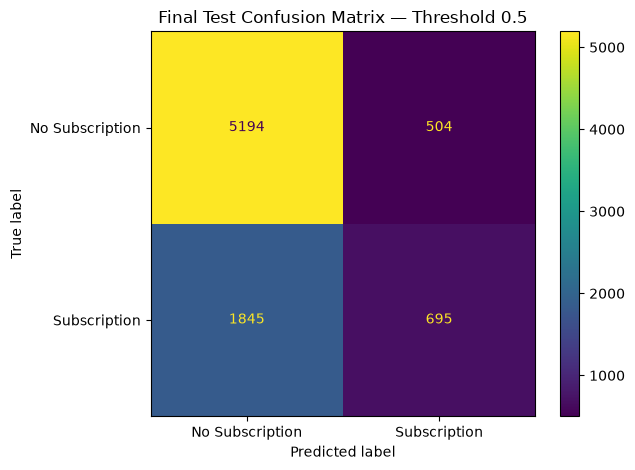

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_05,
    labels=[0, 1],
    display_labels=[
        "No Subscription",
        "Subscription"
    ],
    values_format="d"
)

plt.title(
    "Final Test Confusion Matrix — Threshold 0.5"
)

plt.tight_layout()
plt.show()

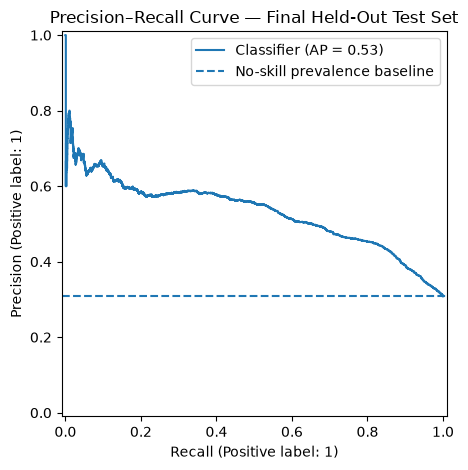

In [119]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.axhline(
    y=TEST_POSITIVE_RATE,
    linestyle="--",
    label="No-skill prevalence baseline"
)

plt.title(
    "Precision–Recall Curve — Final Held-Out Test Set"
)

plt.legend()
plt.tight_layout()
plt.show()

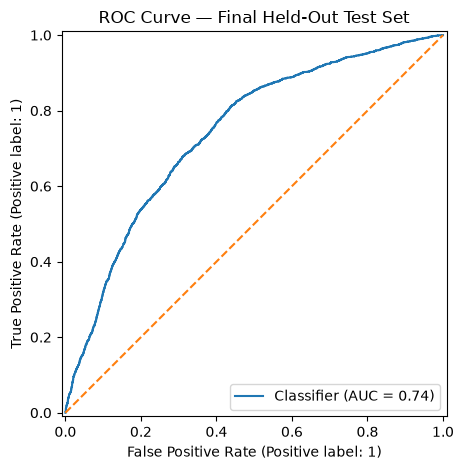

In [120]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve — Final Held-Out Test Set"
)

plt.tight_layout()
plt.show()

In [121]:
test_probability_summary = (
    pd.Series(
        y_test_prob,
        name="predicted_probability"
    )
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

test_probability_summary

count    8238.000000
mean        0.232971
std         0.227299
min         0.018061
1%          0.029169
5%          0.039591
25%         0.075977
50%         0.140827
75%         0.287111
95%         0.776970
99%         0.913803
max         0.994033
Name: predicted_probability, dtype: float64

In [122]:
test_prediction_analysis = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "y_prob": y_test_prob
})

test_prediction_analysis.groupby(
    "y_true"
)["y_prob"].describe()

,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,5698.0,0.180111,0.189652,0.018061,0.067508,0.098433,0.219372,0.991208
1,2540.0,0.351552,0.258007,0.023389,0.141030,0.269281,0.533143,0.994033


In [123]:
development_vs_test = pd.DataFrame({
    "evaluation": [
        "Tuned development CV mean",
        "Final out-of-time test"
    ],
    "average_precision": [
        TUNED_LOGISTIC_AP,
        FINAL_TEST_AP
    ]
})

development_vs_test

,evaluation,average_precision
0,Tuned development CV mean,0.086027
1,Final out-of-time test,0.529870


### Final Test Interpretation

The tuned Logistic Regression was evaluated once on the held-out out-of-time test set after all model-selection decisions had been fixed.

The final test period showed a substantial change in target prevalence. Approximately **30.8%** of test observations were subscribers, compared with much lower subscription rates in the development periods. This confirms that the target distribution changed considerably over time.

The model achieved a final test **Average Precision of approximately 0.530**, compared with a no-skill prevalence baseline of approximately **0.308**. This corresponds to an AP gain of approximately **0.222** and a lift of approximately **1.72×** over the no-skill baseline.

Because Average Precision depends on positive-class prevalence, the raw final-test AP should not be directly compared with the much lower development AP without considering the large difference in class prevalence.

The final test **ROC-AUC was approximately 0.741**, indicating meaningful ability to rank subscribers above non-subscribers in the later time period.

At the conventional classification threshold of 0.5, the model achieved approximately:

- **Precision: 58.0%**
- **Recall: 27.4%**
- **F1-score: 37.2%**
- **Accuracy: 71.5%**

The confusion matrix contained:

- 5,194 true negatives
- 504 false positives
- 1,845 false negatives
- 695 true positives

The model therefore remained conservative at the 0.5 threshold. It identified relatively few customers as subscribers and missed approximately 73% of the customers who actually subscribed.

However, customers who actually subscribed received higher predicted probabilities on average than non-subscribers, showing that the model retained useful ranking information despite substantial overlap between the two classes.

Overall, the final model performed meaningfully above the no-skill baseline in the later test period, but the large temporal shift in subscription prevalence and the high number of false negatives demonstrate that the model should not be treated as a stable production decision rule without further monitoring, calibration, and business-specific threshold design.

No modeling, preprocessing, hyperparameter, or threshold decisions will be changed based on these held-out test results.

## 13. Failure Case Analysis

Final model performance alone does not explain where the model succeeds or fails.

The held-out test predictions will therefore be examined to identify patterns among:

- true positives,
- true negatives,
- false positives,
- false negatives.

Particular attention will be given to false negatives because the model missed a large proportion of actual subscribers at the reference threshold of 0.5.

This analysis is descriptive only. The held-out test set has already been used for final evaluation, so findings from this section will not be used to modify the model or select new features, hyperparameters, or thresholds.

In [125]:
test_error_analysis = X_test.copy()

test_error_analysis["y_true"] = y_test.to_numpy()
test_error_analysis["y_prob"] = y_test_prob
test_error_analysis["y_pred_05"] = y_test_pred_05

conditions = [
    (
        (test_error_analysis["y_true"] == 0)
        & (test_error_analysis["y_pred_05"] == 0)
    ),
    (
        (test_error_analysis["y_true"] == 0)
        & (test_error_analysis["y_pred_05"] == 1)
    ),
    (
        (test_error_analysis["y_true"] == 1)
        & (test_error_analysis["y_pred_05"] == 0)
    ),
    (
        (test_error_analysis["y_true"] == 1)
        & (test_error_analysis["y_pred_05"] == 1)
    )
]

labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

test_error_analysis["outcome"] = np.select(
    conditions,
    labels,
    default="Unclassified"
)

test_error_analysis["outcome"].value_counts()

outcome
True Negative     5194
False Negative    1845
True Positive      695
False Positive     504
Name: count, dtype: int64

In [126]:
probability_by_outcome = (
    test_error_analysis
    .groupby("outcome")["y_prob"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .sort_values("mean")
)

probability_by_outcome

,count,mean,median,min,max
outcome,,,,,
True Negative,5194,0.129166,0.091441,0.018061,0.497837
False Negative,1845,0.211908,0.197206,0.023389,0.499767
False Positive,504,0.705121,0.694900,0.500324,0.991208
True Positive,695,0.722261,0.720963,0.501829,0.994033


In [127]:
most_confident_false_negatives = (
    test_error_analysis[
        test_error_analysis["outcome"]
        == "False Negative"
    ]
    .sort_values(
        "y_prob",
        ascending=True
    )
    .head(10)
)

most_confident_false_negatives

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_true,y_prob,y_pred_05,outcome
35979,54,blue-collar,married,basic.4y,no,unknown,unknown,cellular,may,mon,...,failure,-1.8,92.893,-46.2,1.264,5099.1,1,0.023389,0,False Negative
35643,33,unemployed,married,basic.4y,no,no,no,cellular,may,mon,...,failure,-1.8,92.893,-46.2,1.244,5099.1,1,0.028749,0,False Negative
35182,51,blue-collar,married,basic.9y,unknown,no,no,cellular,may,fri,...,failure,-1.8,92.893,-46.2,1.250,5099.1,1,0.028907,0,False Negative
33178,29,blue-collar,married,basic.4y,unknown,no,no,cellular,may,tue,...,failure,-1.8,92.893,-46.2,1.291,5099.1,1,0.029120,0,False Negative
35174,37,services,married,basic.6y,unknown,yes,no,cellular,may,fri,...,failure,-1.8,92.893,-46.2,1.250,5099.1,1,0.030693,0,False Negative
33320,33,blue-collar,married,high.school,no,yes,no,cellular,may,tue,...,failure,-1.8,92.893,-46.2,1.291,5099.1,1,0.031359,0,False Negative
35912,44,services,married,high.school,no,yes,yes,cellular,may,mon,...,failure,-1.8,92.893,-46.2,1.264,5099.1,1,0.032771,0,False Negative
35371,34,blue-collar,single,basic.6y,unknown,yes,no,cellular,may,fri,...,failure,-1.8,92.893,-46.2,1.250,5099.1,1,0.033264,0,False Negative
33294,43,technician,married,university.degree,unknown,unknown,unknown,cellular,may,tue,...,failure,-1.8,92.893,-46.2,1.291,5099.1,1,0.033511,0,False Negative
35506,44,admin.,married,basic.6y,no,unknown,unknown,cellular,may,mon,...,failure,-1.8,92.893,-46.2,1.244,5099.1,1,0.033569,0,False Negative


In [128]:
most_confident_false_positives = (
    test_error_analysis[
        test_error_analysis["outcome"]
        == "False Positive"
    ]
    .sort_values(
        "y_prob",
        ascending=False
    )
    .head(10)
)

most_confident_false_positives

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_true,y_prob,y_pred_05,outcome
41053,23,student,single,high.school,no,no,no,cellular,oct,wed,...,success,-1.1,94.601,-49.5,1.043,4963.6,0,0.991208,1,False Positive
40966,74,retired,married,university.degree,no,yes,no,cellular,oct,fri,...,success,-1.1,94.601,-49.5,0.993,4963.6,0,0.990228,1,False Positive
40950,81,retired,divorced,basic.4y,no,yes,no,cellular,oct,thu,...,success,-1.1,94.601,-49.5,0.987,4963.6,0,0.988211,1,False Positive
41012,65,retired,married,high.school,no,yes,no,cellular,oct,thu,...,success,-1.1,94.601,-49.5,1.025,4963.6,0,0.987972,1,False Positive
40931,27,admin.,single,university.degree,no,yes,yes,cellular,oct,tue,...,success,-1.1,94.601,-49.5,0.982,4963.6,0,0.986973,1,False Positive
40983,74,retired,divorced,basic.4y,no,yes,no,cellular,oct,mon,...,success,-1.1,94.601,-49.5,1.000,4963.6,0,0.984794,1,False Positive
40986,84,retired,divorced,basic.4y,unknown,yes,yes,cellular,oct,mon,...,success,-1.1,94.601,-49.5,1.000,4963.6,0,0.976572,1,False Positive
38314,74,retired,married,professional.course,no,yes,no,cellular,oct,thu,...,success,-3.4,92.431,-26.9,0.740,5017.5,0,0.970982,1,False Positive
41031,25,student,single,high.school,no,yes,no,cellular,oct,mon,...,success,-1.1,94.601,-49.5,1.032,4963.6,0,0.965115,1,False Positive
38287,36,admin.,single,university.degree,no,yes,no,cellular,oct,wed,...,success,-3.4,92.431,-26.9,0.742,5017.5,0,0.957937,1,False Positive


In [129]:
def outcome_rate_by_category(
    data,
    column
):
    counts = pd.crosstab(
        data[column],
        data["outcome"]
    )

    rates = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    return counts, rates

In [130]:
poutcome_error_counts, poutcome_error_rates = (
    outcome_rate_by_category(
        test_error_analysis,
        "poutcome"
    )
)

poutcome_error_counts

outcome,False Negative,False Positive,True Negative,True Positive
poutcome,,,,
failure,431,87,1578,49
nonexistent,1108,223,3436,121
success,306,194,180,525


In [131]:
poutcome_error_rates

outcome,False Negative,False Positive,True Negative,True Positive
poutcome,,,,
failure,0.200932,0.040559,0.735664,0.022844
nonexistent,0.226678,0.045622,0.702946,0.024755
success,0.253942,0.160996,0.149378,0.435685


In [132]:
contact_error_counts, contact_error_rates = (
    outcome_rate_by_category(
        test_error_analysis,
        "contact"
    )
)

contact_error_counts

outcome,False Negative,False Positive,True Negative,True Positive
contact,,,,
cellular,1679,434,4479,653
telephone,166,70,715,42


In [133]:
contact_error_rates

outcome,False Negative,False Positive,True Negative,True Positive
contact,,,,
cellular,0.231746,0.059903,0.618219,0.090131
telephone,0.167170,0.070493,0.720040,0.042296


In [134]:
job_error_counts, job_error_rates = (
    outcome_rate_by_category(
        test_error_analysis,
        "job"
    )
)

job_error_counts

outcome,False Negative,False Positive,True Negative,True Positive
job,,,,
admin.,589,138,1450,205
blue-collar,181,31,1048,35
entrepreneur,37,6,144,8
housemaid,53,8,105,14
management,120,30,325,49
retired,194,93,316,127
self-employed,55,17,180,13
services,120,22,477,25
student,126,52,261,89


In [135]:
job_error_rates

outcome,False Negative,False Positive,True Negative,True Positive
job,,,,
admin.,0.247271,0.057935,0.608732,0.086062
blue-collar,0.139768,0.023938,0.809266,0.027027
entrepreneur,0.189744,0.030769,0.738462,0.041026
housemaid,0.294444,0.044444,0.583333,0.077778
management,0.229008,0.057252,0.620229,0.093511
retired,0.265753,0.127397,0.432877,0.173973
self-employed,0.207547,0.064151,0.679245,0.049057
services,0.186335,0.034161,0.740683,0.038820
student,0.238636,0.098485,0.494318,0.168561


In [136]:
month_error_counts, month_error_rates = (
    outcome_rate_by_category(
        test_error_analysis,
        "month"
    )
)

month_error_counts

outcome,False Negative,False Positive,True Negative,True Positive
month,,,,
apr,94,1,76,3
aug,305,31,588,79
dec,75,3,81,13
jul,205,14,233,37
jun,310,40,533,61
mar,101,11,103,49
may,409,23,3010,44
nov,157,17,242,69
oct,18,344,34,255


In [137]:
month_error_rates

outcome,False Negative,False Positive,True Negative,True Positive
month,,,,
apr,0.540230,0.005747,0.436782,0.017241
aug,0.304088,0.030907,0.586241,0.078764
dec,0.436047,0.017442,0.470930,0.075581
jul,0.419223,0.028630,0.476483,0.075665
jun,0.328390,0.042373,0.564619,0.064619
mar,0.382576,0.041667,0.390152,0.185606
may,0.117326,0.006598,0.863454,0.012622
nov,0.323711,0.035052,0.498969,0.142268
oct,0.027650,0.528418,0.052227,0.391705


In [138]:
subscriber_cases = test_error_analysis[
    test_error_analysis["y_true"] == 1
].copy()

subscriber_cases["missed_subscriber"] = (
    subscriber_cases["y_pred_05"] == 0
)

subscriber_miss_rate = (
    subscriber_cases["missed_subscriber"]
    .mean()
)

print(
    "Overall subscriber miss rate:",
    round(subscriber_miss_rate, 4)
)

Overall subscriber miss rate: 0.7264


In [139]:
subscriber_miss_by_job = (
    subscriber_cases
    .groupby("job")
    .agg(
        actual_subscribers=(
            "y_true",
            "size"
        ),
        missed_subscribers=(
            "missed_subscriber",
            "sum"
        ),
        miss_rate=(
            "missed_subscriber",
            "mean"
        )
    )
    .sort_values(
        "miss_rate",
        ascending=False
    )
)

subscriber_miss_by_job

,actual_subscribers,missed_subscribers,miss_rate
job,,,
blue-collar,216,181,0.837963
services,145,120,0.827586
entrepreneur,45,37,0.822222
self-employed,68,55,0.808824
housemaid,67,53,0.791045
unknown,22,17,0.772727
unemployed,101,77,0.762376
admin.,794,589,0.741814
technician,377,276,0.732095


In [140]:
subscriber_miss_by_contact = (
    subscriber_cases
    .groupby("contact")
    .agg(
        actual_subscribers=(
            "y_true",
            "size"
        ),
        missed_subscribers=(
            "missed_subscriber",
            "sum"
        ),
        miss_rate=(
            "missed_subscriber",
            "mean"
        )
    )
    .sort_values(
        "miss_rate",
        ascending=False
    )
)

subscriber_miss_by_contact

,actual_subscribers,missed_subscribers,miss_rate
contact,,,
telephone,208,166,0.798077
cellular,2332,1679,0.719983


In [141]:
subscriber_miss_by_poutcome = (
    subscriber_cases
    .groupby("poutcome")
    .agg(
        actual_subscribers=(
            "y_true",
            "size"
        ),
        missed_subscribers=(
            "missed_subscriber",
            "sum"
        ),
        miss_rate=(
            "missed_subscriber",
            "mean"
        )
    )
    .sort_values(
        "miss_rate",
        ascending=False
    )
)

subscriber_miss_by_poutcome

,actual_subscribers,missed_subscribers,miss_rate
poutcome,,,
nonexistent,1229,1108,0.901546
failure,480,431,0.897917
success,831,306,0.368231


In [142]:
subscriber_miss_by_month = (
    subscriber_cases
    .groupby("month")
    .agg(
        actual_subscribers=(
            "y_true",
            "size"
        ),
        missed_subscribers=(
            "missed_subscriber",
            "sum"
        ),
        miss_rate=(
            "missed_subscriber",
            "mean"
        )
    )
    .sort_values(
        "miss_rate",
        ascending=False
    )
)

subscriber_miss_by_month

,actual_subscribers,missed_subscribers,miss_rate
month,,,
apr,97,94,0.969072
may,453,409,0.902870
dec,88,75,0.852273
jul,242,205,0.847107
jun,371,310,0.835580
aug,384,305,0.794271
nov,226,157,0.694690
mar,150,101,0.673333
sep,256,171,0.667969


In [143]:
subscriber_numeric_comparison = (
    test_error_analysis[
        test_error_analysis["y_true"] == 1
    ]
    .groupby("outcome")[
        NUMERIC_FEATURES
    ]
    .median()
    .T
)

subscriber_numeric_comparison

outcome,False Negative,True Positive
age,37.000,37.000
campaign,1.000,1.000
previous,0.000,1.000
emp.var.rate,-1.800,-1.800
cons.price.idx,92.963,93.369
cons.conf.idx,-38.300,-37.500
euribor3m,0.879,0.767
nr.employed,5023.500,5008.700


### Failure Analysis Findings

Failure analysis showed that false negatives are the primary classification error at the reference threshold of 0.5.

The model missed **1,845 of 2,540 actual subscribers**, corresponding to an overall subscriber miss rate of approximately **72.6%**.

Predicted probabilities still contained useful ranking information among negative predictions. False negatives received a median predicted probability of approximately **0.197**, compared with approximately **0.091** for true negatives. However, several strongly misclassified cases were also observed, showing that the errors cannot be explained by the decision threshold alone.

Previous campaign outcome was strongly associated with the model's ability to identify subscribers. Approximately **90%** of subscribers with either no previous campaign outcome or a previous failed campaign were missed, while the miss rate among customers with a previous campaign success was approximately **37%**. The median number of previous contacts was also higher among true positives than false negatives.

Substantial variation was observed across contact months. Subscriber miss rates were particularly high in several months, including April and May, while the miss rate in October was much lower. October also contained a relatively large number of false-positive predictions. This indicates that model behavior changes considerably across time periods.

These month-level differences should not be interpreted as causal effects of the calendar month. Month may act as a proxy for changing campaign strategies, economic conditions, customer populations, or other time-dependent factors.

Subscriber miss rates also varied across occupational groups. Blue-collar, services, entrepreneur, and self-employed subscribers showed relatively high miss rates, while retired and student subscribers were identified more successfully. These comparisons are descriptive only, and results for smaller groups should be interpreted cautiously.

Telephone-contacted subscribers had a higher observed miss rate than cellular-contacted subscribers, although this difference was smaller than the variation associated with previous campaign outcome and contact month.

Median numerical characteristics were relatively similar between false negatives and true positives for several variables, including age and campaign contact count. Previous campaign activity showed a clearer difference, while some economic indicators also differed modestly between the two groups.

Overall, the failure analysis suggests that the model relies heavily on historical campaign signals and that its prediction behavior changes substantially across time periods. These findings reinforce the need for temporal monitoring, probability calibration, and careful threshold design before any real-world use.

Because these findings were obtained from the final held-out test set, they are used only to document model limitations and are not used to modify the already evaluated model.